In [1]:
! pip install numpy
! pip install matplotlib
! pip install pandas
! pip install scipy
! pip install statsmodels
! pip install seaborn
! pip install tqdm 


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


# Todo
- check whether people reuse names in rounds 1-3, so that round 4 they would have an expectation of success in reuse but then don't get it.
- check what happens if we average the submission times and only have one result per group


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
from scipy import stats
import seaborn as sns


# Processing pipeline (for supplement)

1. Load all `revision_202509/batch_*.scienceData.jsonl` records with `sampleId != "missing"`.
2. Extract treatment condition, game identifiers, connection/browser metadata, QC responses, and stage submission times.
3. For labeling stages, use submit-button timestamps; if missing (auto-advance), set labeling time to 300 seconds (5-minute timeout).
4. Parse recall prompts, lowercase/strip responses, and compute per-image matches only when both partners responded identically.
5. Score each round as the count of unique matched labels (0–8 scale, one per image).
6. Exclude participants with `num_reports >= 3` or near-complete nonresponse in recall (`empty_recall_counts >= 10`).
7. Aggregate to the game (pair) level: one row per game/treatment; use the max labeling time across partners; keep accuracy (identical within pairs).
8. Primary prereg outcomes: round 3 labeling time (seconds) and round 4 accuracy (# correct, 0–8), using only `schema` and `nonschema`.


In [6]:
# read science data line by line, parse json, and store in a list

################## Pilots Data #########################
# filename = 'batch_20240409_1520_turkPilot.scienceData.jsonl'
# filename = 'batch_20240410_1435_turkPilot2.scienceData.jsonl'
# filename = 'revision_202504/batch_20250421_1915_pilot.scienceData.jsonl'
# filename = 'revision_202504/batch_20250429_1536_pilot.scienceData.jsonl'
# filename = 'revision_202508/batch_20250903_1711_pilot.scienceData.jsonl'
# filename = 'revision_202509/batch_20250915_2010_pilot.scienceData.jsonl'
# filename = 'revision_202509/batch_20251006_1952_pilot.scienceData.jsonl'
# filenames = [
#     'revision_202509/batch_20250915_2010_pilot.scienceData.jsonl',
#     'revision_202509/batch_20251006_1952_pilot.scienceData.jsonl',
#     'revision_202509/batch_20251105_1931_pilot.scienceData.jsonl'
# ]
# filenames = glob.glob('revision_202509/batch_*.scienceData.jsonl')

################## Study Data #########################
filenames = glob.glob('../data/study_1_schema_nonschema/batch_*.scienceData.jsonl')
filenames += glob.glob('revision_202509/batch_*.scienceData.jsonl')

print("Filenames to process:", filenames)
raw = []

for filename in filenames:
    with open(filename) as f:
        for line in f:
            parsed = json.loads(line)
            if parsed['sampleId'] != 'missing':
                raw.append(parsed)


all_data = pd.DataFrame()
all_data["treatment"] = [row["treatment"]["name"] for row in raw]
all_data["treatmentGroup"] = [row["treatment"]["name"].split("_")[0] for row in raw]
all_data["sampleId"] = [row["sampleId"] for row in raw]
all_data["gameId"] = [row["gameId"][-6:] for row in raw]
all_data["gameId_full"] = [row["gameId"] for row in raw]

print("Initial data shape:", all_data.shape)

# sanity check: truncated gameId is unique in this dataset
_gameid_collisions = all_data.groupby("gameId")["gameId_full"].nunique()
assert _gameid_collisions.max() == 1, f"Truncated gameId collision(s): {_gameid_collisions[_gameid_collisions > 1].index.tolist()}"

# parse connection info into columns
connection_info = pd.DataFrame([row['connectionInfo'] for row in raw])
all_data = pd.concat([all_data, connection_info], axis=1)

# Parse browser info into columns
browser_info = pd.DataFrame([row['browserInfo'] for row in raw])
all_data = pd.concat([all_data, browser_info], axis=1)

# Parse QC survey into columns
QC = pd.DataFrame([(row['QCSurvey']['responses'] if row['QCSurvey'] != "missing" else {}) for row in raw])
all_data = pd.concat([all_data, QC], axis=1)

# Parse participation data into columns
all_data["num_reports"] = [len(row["reports"]) for row in raw]

# parse labeling submission times into columns
# these are taken from the submit button timings
submit_times = pd.DataFrame([{k: v['time'] for k, v in row['stageSubmissions'].items()} for row in raw])
columns = ["time_"+"_".join(col.replace("submitButton_", "").split("_")[-3:]) for col in submit_times.columns]
submit_times.columns = columns
submit_times = submit_times[sorted(submit_times.columns)]

labeling_times = [col for col in submit_times.columns if "labeling" in col]
missing_labeling_counts = submit_times[labeling_times].isna().sum()
# print("Missing labeling times (count before timeout fill):", missing_labeling_counts.to_dict())

submit_times[labeling_times] = submit_times[labeling_times].fillna(300) # fill missing labeling times with 5 minutes, the max allowed
assert submit_times[labeling_times].isna().sum().sum() == 0

all_data = pd.concat([all_data, submit_times[labeling_times]], axis=1)

# parse labels into columns
def extract_word(cell):
    for i in range(8):
        cell = cell.replace(f"Image {i+1}:", "")
    return cell.strip()

def get_labels(row):
    keys = ['prompt_labeling_1a', 'prompt_labeling_1b', 'prompt_labeling_1c',
            'prompt_labeling_2', 'prompt_labeling_3', 'prompt_labeling_4']
    labels = {}
    for key in keys:
        try:
            raw_labels_for_round = row['prompts'][key]['value'].split("\n")
            raw_labels_for_round = [extract_word(label) for label in raw_labels_for_round]
            for i, word in enumerate(raw_labels_for_round):
                labels[key.replace("prompt_labeling_", "label_") + "_" + str(i)] = word
        except (KeyError, TypeError, AttributeError):
            continue

    return labels
    
labels = pd.DataFrame([get_labels(row) for row in raw])
labels = labels[sorted(labels.columns)]
all_data = pd.concat([all_data, labels], axis=1)

# Parse recall responses into columns
# standardize recall responses to lowercase and strip leading and trailing whitespace
recall = pd.DataFrame([{key: d['value'].lower().strip() for key, d in row['prompts'].items() if 'recall' in key} for row in raw])
recall.columns = [col.replace('prompt_recall_', 'recall_') for col in recall.columns]
recall = recall[sorted(recall.columns)].fillna("") # fill missing recall responses with empty string
expected_recall_counts = {"1a": 2, "1b": 4, "1c": 8, "2": 8, "3": 8, "4": 8}
observed_rounds = {col.split("_")[1] for col in recall.columns}
assert observed_rounds == set(expected_recall_counts), f"Unexpected recall rounds: {observed_rounds}"
observed_recall_counts = {round_key: sum(col.split("_")[1] == round_key for col in recall.columns) for round_key in expected_recall_counts}
assert observed_recall_counts == expected_recall_counts, f"Recall column mismatch: {observed_recall_counts}"
all_data = pd.concat([all_data, recall], axis=1)

# # Compute total recall time
# total_recall_time = pd.DataFrame()
# for round in sorted(set([col.split("_")[1] for col in recall.columns])):
#     cols = [col for col in all_data.columns if "time_recall_"+round in col]
#     total_recall_time["time_recall_total_"+round] = all_data[cols].sum(axis=1)

# all_data = pd.concat([all_data, total_recall_time], axis=1)

# Compute matches (true/false) and merge into columns
matches = (all_data.groupby("gameId")[recall.columns].nunique() == 1) & (all_data.groupby("gameId")[recall.columns].count() == 2)  # binary did they match, and did they both participate?
matches.columns = [col.replace("recall_", "match_") for col in matches.columns]
all_data = pd.merge(left=all_data, right=matches, left_on="gameId", right_index=True)


# find matched recalls (i.e., the actual words that were recalled the same)
matched_recalls = pd.DataFrame()
for match_col in [col for col in all_data.columns if "match_" in col]:
    recall_col = match_col.replace("match_", "recall_")
    matched_recall_col = match_col.replace("match_", "matched_recall_")
    all_data[matched_recall_col] = all_data[recall_col]*all_data[match_col] # mask out non-matches (they are empty strings)


# compute points only on unique labels
accuracy_df = pd.DataFrame()
for round in ["1a", "1b", "1c", "2", "3", "4"]:
    cols = [col for col in  all_data if f"matched_recall_{round}_" in col]
    all_data[f"accuracy_{round}"] = all_data[cols].replace("", np.nan).nunique(axis=1).astype(float)  # number correct (0–8 scale)




print("Before filtering:", all_data.groupby("treatment")["accuracy_1a"].count().to_dict())
print("By treatment counts:", all_data.groupby("treatment")["sampleId"].count().to_dict())
# filter groups with a missing conversation partner
all_data = all_data[all_data["num_reports"]<3]  # not missing from conversation
participant_counts = all_data.groupby("gameId")["sampleId"].nunique()
assert participant_counts.max() <= 2, "More than two participants found for a gameId"
# print("Participants per gameId:", participant_counts.value_counts().to_dict())
print("Data shape after filtering for conversation participation:", all_data.shape)



# filter groups that did not have both participants do the recall
all_data['empty_recall_counts'] = (all_data[[col for col in  recall.columns]] == "").sum(axis=1)
all_data = all_data[all_data['empty_recall_counts'] < 13]  # participating in recall ## Note that we had meant to preregister this as <13, but we got the language confused and said that we'd exclude people who had more than 13 empty recall responses, which is actually a much more lenient cutoff. We'll go with it, as that's what we preregistered, but we should be clear about this in the paper and consider a more stringent cutoff in future work.

# find out pairs that have both partners with responses
pair_complete = (all_data.groupby(["gameId"])[["accuracy_3", "accuracy_4"]].count() == 2).all(axis=1)
# filter to only pairs with both partners
all_data = all_data[all_data["gameId"].isin(pair_complete[pair_complete].index)]
print("Treatment counts with complete groups", all_data.groupby("treatment")["accuracy_1a"].count().to_dict())


treatment_counts = all_data.groupby("gameId")["treatment"].nunique()
assert treatment_counts.max() == 1, "Mixed treatments within a gameId"


print("condition counts:", all_data.groupby("treatment")["sampleId"].count())

all_data.to_csv("pilot_analysis_results.csv", index=False)

pd.options.display.max_rows = None
print(all_data.shape)

#all_data[all_data["gameId"] == raw[0]["gameId"][-6:]].T

all_data[all_data["treatment"].isin(["nonschema", "schema"])].sort_values(by=['treatmentGroup', 'treatment', 'gameId']).T
all_data.to_csv("all_data_extracted.csv", index=False)


Filenames to process: ['../data/study_1_schema_nonschema/batch_20260203_2156_study1.scienceData.jsonl', '../data/study_1_schema_nonschema/batch_20260212_1704_study1.scienceData.jsonl', '../data/study_1_schema_nonschema/batch_20260220_2216_study1.scienceData.jsonl', '../data/study_1_schema_nonschema/batch_20260220_2045_study1.scienceData.jsonl', '../data/study_1_schema_nonschema/batch_20260211_1437_study1.scienceData.jsonl', '../data/study_1_schema_nonschema/batch_20260205_1753_study1.scienceData.jsonl', '../data/study_1_schema_nonschema/batch_20260203_1909_study1.scienceData.jsonl', 'revision_202509/batch_20251209_1551_pilot.scienceData.jsonl', 'revision_202509/batch_20251209_1914_pilot.scienceData.jsonl', 'revision_202509/batch_20260309_1843_pilot.scienceData.jsonl', 'revision_202509/batch_20251105_1931_pilot.scienceData.jsonl', 'revision_202509/batch_20260106_2205_pilot.scienceData.jsonl', 'revision_202509/batch_20250915_2010_pilot.scienceData.jsonl', 'revision_202509/batch_20251006_

/var/folders/2l/3kmvzs0s1sggnw_9sl0ls8080000gn/T/ipykernel_96117/3807044728.py:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  QC["videoQuality"].replace("NA", np.nan).astype(float).value_counts().sort_index().plot(kind='bar', title="Video Quality")


Comments:
4GBFHG nothing
ES0E4B Partner only was audio not video. Some communication barrier with language with my partner.
MARST6 It is fun (but for the time should be paid more as this is far below minimum wage and people's time and work should be respected). It is a fun activity and exciting to even briefly meet others on Prolific. I wish there were more like this.
MBQ84F no it all was very good
E8T5Z5 This was a fantastically fun study! I'd love to participate in a similar one again in the future. Thank you very much for this opportunity!
V85HRK Nothing comes to mind.
V85HRK great study, good luck with your results.  
SFQ0P4 It was a good experience.
TY9XBR I enjoyed the experience
GYV382 was fun thanks
MD8EBA thank you for the opportunity 
PP2GEH Great study!
SJME17 nothing
KHQ8YT That was something new and unique, and fun! Thanks!
YTYFXS The only time I played a similar version to this game was when my partners left so I could even finish the study so this still was like my first

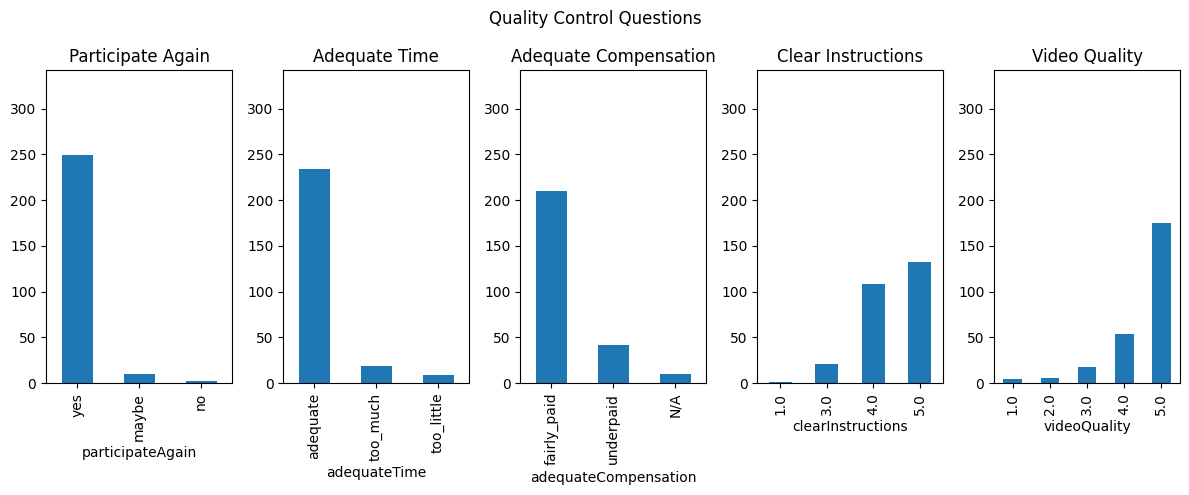

In [38]:
# Plot QC data

plt.figure(figsize=(12, 5))
plt.subplot(1,5,1)
QC["participateAgain"].value_counts().plot(kind='bar', title="Participate Again")
plt.ylim(0, len(QC))

plt.subplot(1,5,2)
# QC["adequateTime"].value_counts().loc[["too_little", "adequate", "too_much"]].plot(kind='bar', title="Adequate Time")
QC["adequateTime"].value_counts().plot(kind='bar', title="Adequate Time")
plt.ylim(0, len(QC))

plt.subplot(1,5,3)
QC["adequateCompensation"].value_counts().plot(kind='bar', title="Adequate Compensation")
plt.ylim(0, len(QC))

plt.subplot(1,5,4)
QC["clearInstructions"].value_counts().sort_index().plot(kind='bar', title="Clear Instructions")
plt.ylabel('')
plt.ylim(0, len(QC))

plt.subplot(1,5,5)
QC["videoQuality"].replace("NA", np.nan).astype(float).value_counts().sort_index().plot(kind='bar', title="Video Quality")
plt.ylabel('')
plt.ylim(0, len(QC))

plt.suptitle("Quality Control Questions")
plt.tight_layout()

print("Comments:")
for i, row in all_data.iterrows():
        if len(str(row["textExpansion"])) > 5:
            print(row["gameId"], row["textExpansion"])
            


# QC

In [39]:
# Exclude groups that had trouble with audio/video or other communication issues based on feedback.

flagged_groups = [
    "ES0E4B", # Partner only was audio not video. Some communication barrier with language with my partner.
    "RHNS8Z", # Despite him not being able to hear me after the first round, we communicated well through gestures and facial expressions.
    "DA5DS8", # well my partner mention her mic wasnt working
]

all_data = all_data[~all_data["gameId"].isin(flagged_groups)]


In [40]:
# Our analysis is at the group level, so we need to aggregate the data to the gameId level. 
# We take the max of each column within each group

data = all_data[[
    "treatment", "gameId", 
    "accuracy_1a", "accuracy_1b", "accuracy_1c", "accuracy_2", "accuracy_3", "accuracy_4", 
    "time_labeling_1a", "time_labeling_1b", "time_labeling_1c", "time_labeling_2", "time_labeling_3", "time_labeling_4"
]]
acc_cols = [col for col in data.columns if col.startswith("accuracy_")]
assert data.groupby(["treatment","gameId"])[acc_cols].std().max().max() == 0 # check accuracy identical within each gameId


# IMPORTANT: this is a per-column max within each (treatment, gameId) group
# (i.e., element-wise max across the two partner rows), NOT “pick the row with the max in some column”.
data = data.groupby(["treatment","gameId"]).max(numeric_only=True)

# recompute score based on max time for the group
data["score_1a"] = data["accuracy_1a"] / data["time_labeling_1a"] * 60  # correct labels per min
data["score_1b"] = data["accuracy_1b"] / data["time_labeling_1b"] * 60
data["score_1c"] = data["accuracy_1c"] / data["time_labeling_1c"] * 60
data["score_2"]  = data["accuracy_2"]  / data["time_labeling_2"]  * 60
data["score_3"]  = data["accuracy_3"]  / data["time_labeling_3"]  * 60
data["score_4"]  = data["accuracy_4"]  / data["time_labeling_4"]  * 60

print("Treatment counts with complete groups", data.groupby("treatment")["accuracy_1a"].count().to_dict())

data.reset_index(inplace=True)
data = data[data["treatment"].isin(["nonschema", "schema", "schema_tangrams", "nonschema_tangrams"])]

data


Treatment counts with complete groups {'nonschema': 45, 'nonschema_black_and_white': 8, 'nonschema_tangrams': 13, 'schema': 50, 'schema_black_and_white': 8, 'schema_nonschema': 3, 'schema_tangrams': 17}


,treatment,gameId,accuracy_1a,accuracy_1b,accuracy_1c,accuracy_2,accuracy_3,accuracy_4,time_labeling_1a,time_labeling_1b,time_labeling_1c,time_labeling_2,time_labeling_3,time_labeling_4,score_1a,score_1b,score_1c,score_2,score_3,score_4
0,nonschema,14RBNC,2.0,4.0,8.0,8.0,6.0,7.0,95.275,128.718,141.991,192.847,236.068,191.411,1.259512,1.864541,3.380496,2.489020,1.524984,2.194231
1,nonschema,3NZWFJ,2.0,4.0,8.0,7.0,8.0,8.0,34.187,31.702,71.608,110.455,67.555,74.667,3.510106,7.570500,6.703162,3.802453,7.105322,6.428543
2,nonschema,407XTD,0.0,4.0,8.0,8.0,8.0,8.0,56.009,64.227,86.899,163.500,164.452,144.395,0.000000,3.736746,5.523654,2.935780,2.918785,3.324215
3,nonschema,4GBFHG,2.0,4.0,6.0,5.0,8.0,8.0,94.728,139.123,149.607,300.000,213.229,300.000,1.266785,1.725092,2.406305,1.000000,2.251101,1.600000
4,nonschema,57ZQA5,2.0,4.0,7.0,5.0,8.0,8.0,46.921,48.524,94.056,127.987,121.580,121.808,2.557490,4.946006,4.465425,2.343988,3.948018,3.940628
5,nonschema,868SK9,2.0,4.0,8.0,7.0,8.0,7.0,115.863,136.387,124.530,187.601,217.375,152.201,1.035706,1.759699,3.854493,2.238794,2.208166,2.759509
6,nonschema,987DM5,1.0,3.0,8.0,7.0,8.0,8.0,41.528,38.989,57.586,102.897,139.079,131.244,1.444808,4.616687,8.335359,4.081752,3.451276,3.657310
7,nonschema,A5SQN4,2.0,4.0,4.0,7.0,7.0,6.0,83.244,37.636,246.322,135.489,163.896,168.582,1.441545,6.376873,0.974334,3.099883,2.562601,2.135459
8,nonschema,ACFAK0,2.0,4.0,8.0,6.0,8.0,5.0,144.458,151.970,117.963,300.000,237.384,274.837,0.830691,1.579259,4.069073,1.200000,2.022040,1.091556
9,nonschema,B78GBJ,2.0,4.0,8.0,7.0,7.0,8.0,74.549,79.479,116.520,151.513,141.194,134.407,1.609680,3.019666,4.119464,2.772039,2.974631,3.571243


# Power Calculation for Study 2

Study 2 uses a 2x2 design: Schema vs Non-Schema x schema-ambiguous vs schema-incompatible change in Round 4.

The primary test (H1) is a restricted permutation test on the interaction contrast:
penalty(ambiguous) - penalty(incompatible), where penalty = mean(Schema) - mean(Non-Schema).

We estimate effect sizes from pilot data and use simulation to determine required sample size.

Pilot conditions:
- schema / nonschema = schema-ambiguous (same as Study 1)
- schema_tangrams / nonschema_tangrams = schema-incompatible

In [41]:
# Pilot data summary for the 4 Study 2 conditions
conditions = {
    "Schema, Ambiguous": data[data["treatment"] == "schema"]["accuracy_4"],
    "Non-Schema, Ambiguous": data[data["treatment"] == "nonschema"]["accuracy_4"],
    "Schema, Incompatible": data[data["treatment"] == "schema_tangrams"]["accuracy_4"],
    "Non-Schema, Incompatible": data[data["treatment"] == "nonschema_tangrams"]["accuracy_4"],
}

print("Pilot data: Round 4 accuracy by condition")
print("=" * 60)
for name, vals in conditions.items():
    print(f"  {name:30s}: n={len(vals):3d}, mean={vals.mean():.2f}, sd={vals.std(ddof=1):.2f}, median={vals.median():.1f}")

# Compute the interaction contrast from pilot data
penalty_amb = conditions["Schema, Ambiguous"].mean() - conditions["Non-Schema, Ambiguous"].mean()
penalty_inc = conditions["Schema, Incompatible"].mean() - conditions["Non-Schema, Incompatible"].mean()
interaction = penalty_amb - penalty_inc

print(f"\nPenalty (Schema - Non-Schema):")
print(f"  Ambiguous:    {penalty_amb:.2f}")
print(f"  Incompatible: {penalty_inc:.2f}")
print(f"  Interaction contrast: {interaction:.2f}")

# Within-cell SDs (pooled across all 4 cells)
all_sds = [v.std(ddof=1) for v in conditions.values()]
pooled_sd = np.sqrt(np.mean([s**2 for s in all_sds]))
print(f"\nPooled within-cell SD: {pooled_sd:.2f}")
print(f"\nNote: incompatible arm has small pilot samples (n={len(conditions['Schema, Incompatible'])} and {len(conditions['Non-Schema, Incompatible'])})")


Pilot data: Round 4 accuracy by condition
  Schema, Ambiguous             : n= 50, mean=5.22, sd=2.22, median=5.5
  Non-Schema, Ambiguous         : n= 45, mean=7.20, sd=1.16, median=8.0
  Schema, Incompatible          : n= 17, mean=5.29, sd=2.23, median=6.0
  Non-Schema, Incompatible      : n= 13, mean=6.85, sd=1.41, median=7.0

Penalty (Schema - Non-Schema):
  Ambiguous:    -1.98
  Incompatible: -1.55
  Interaction contrast: -0.43

Pooled within-cell SD: 1.82

Note: incompatible arm has small pilot samples (n=17 and 13)


In [34]:
# Simulation-based power analysis for the restricted permutation test (H1)
#
# Strategy: for each candidate sample size N (per cell), simulate data under
# the pilot-estimated effect sizes, run the restricted permutation test,
# and record whether we reject H0. Power = fraction of simulations that reject.

from scipy import stats

# Pilot-estimated parameters
mu_schema_amb = conditions["Schema, Ambiguous"].mean()
mu_nonschema_amb = conditions["Non-Schema, Ambiguous"].mean()
mu_schema_inc = conditions["Schema, Incompatible"].mean()
mu_nonschema_inc = conditions["Non-Schema, Incompatible"].mean()

# Use per-cell SDs from pilot data
sd_schema_amb = conditions["Schema, Ambiguous"].std(ddof=1)
sd_nonschema_amb = conditions["Non-Schema, Ambiguous"].std(ddof=1)
sd_schema_inc = conditions["Schema, Incompatible"].std(ddof=1)
sd_nonschema_inc = conditions["Non-Schema, Incompatible"].std(ddof=1)

def run_permutation_test(schema_amb, nonschema_amb, schema_inc, nonschema_inc, n_perm=2000):
    """Restricted permutation test: permute change-type labels within each Schema condition."""
    # Observed interaction contrast
    penalty_a = schema_amb.mean() - nonschema_amb.mean()
    penalty_i = schema_inc.mean() - nonschema_inc.mean()
    observed = penalty_a - penalty_i
    
    count = 0
    # Permute within Schema groups
    schema_combined = np.concatenate([schema_amb, schema_inc])
    n_sa = len(schema_amb)
    # Permute within Non-Schema groups
    nonschema_combined = np.concatenate([nonschema_amb, nonschema_inc])
    n_na = len(nonschema_amb)
    
    for _ in range(n_perm):
        s_perm = np.random.permutation(schema_combined)
        n_perm_s = np.random.permutation(nonschema_combined)
        p_a = s_perm[:n_sa].mean() - n_perm_s[:n_na].mean()
        p_i = s_perm[n_sa:].mean() - n_perm_s[n_na:].mean()
        if p_a - p_i <= observed:
            count += 1
    return count / n_perm

np.random.seed(123)
n_per_cell_options = [15, 20, 25, 30, 35, 40, 50, 60]
n_simulations = 500  # per sample size
n_perm = 2000  # permutations per test
alpha = 0.05

print("Simulation-based power for H1 (restricted permutation test)")
print("Using pilot-estimated cell means and SDs")
print(f"Simulations per N: {n_simulations}, Permutations per test: {n_perm}")
print("=" * 60)

power_results = []
for n in n_per_cell_options:
    rejections = 0
    for _ in range(n_simulations):
        # Simulate data: draw from normal, then clip to [0, 8] and round
        sim_sa = np.clip(np.round(np.random.normal(mu_schema_amb, sd_schema_amb, n)), 0, 8)
        sim_na = np.clip(np.round(np.random.normal(mu_nonschema_amb, sd_nonschema_amb, n)), 0, 8)
        sim_si = np.clip(np.round(np.random.normal(mu_schema_inc, sd_schema_inc, n)), 0, 8)
        sim_ni = np.clip(np.round(np.random.normal(mu_nonschema_inc, sd_nonschema_inc, n)), 0, 8)
        
        p_val = run_permutation_test(sim_sa, sim_na, sim_si, sim_ni, n_perm)
        if p_val <= alpha:
            rejections += 1
    
    power = rejections / n_simulations
    power_results.append((n, power))
    print(f"  N per cell = {n:3d}  (total = {4*n:4d})  |  power = {power:.3f}")

print(f"\nTarget: 80% power => look for N per cell where power >= 0.80")


Simulation-based power for H1 (restricted permutation test)
Using pilot-estimated cell means and SDs
Simulations per N: 500, Permutations per test: 2000


KeyboardInterrupt: 

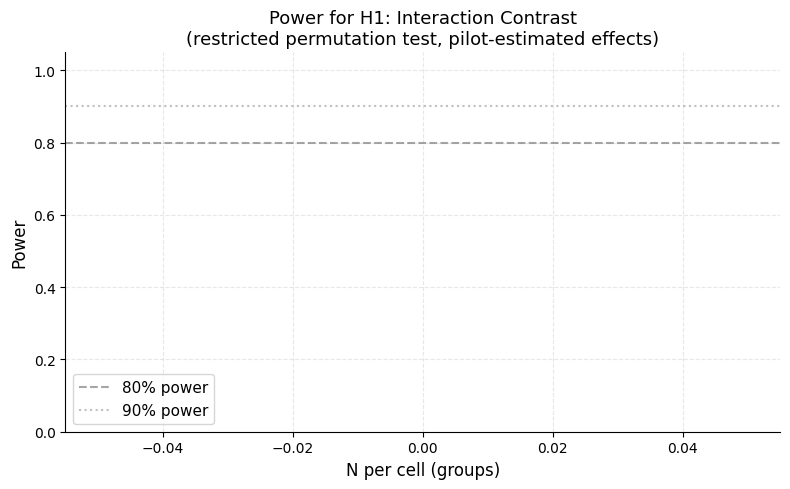

In [35]:
# Plot power curve
ns = [r[0] for r in power_results]
powers = [r[1] for r in power_results]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ns, powers, "o-", color="#E85D75", linewidth=2, markersize=8)
ax.axhline(0.80, color="gray", linestyle="--", alpha=0.7, label="80% power")
ax.axhline(0.90, color="gray", linestyle=":", alpha=0.5, label="90% power")
ax.set_xlabel("N per cell (groups)", fontsize=12)
ax.set_ylabel("Power", fontsize=12)
ax.set_title("Power for H1: Interaction Contrast\n(restricted permutation test, pilot-estimated effects)", fontsize=13)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


In [44]:
# Extended power analysis: larger sample sizes + sensitivity analysis
# Q1: At pilot-estimated effect (interaction ~ 0), what N would we need?
# Q2: What if the true interaction is larger than the noisy pilot estimate?

from scipy import stats

# Re-use pilot parameters from above
# Also run for hypothetical interaction sizes

def simulate_power(mu_sa, mu_na, mu_si, mu_ni, 
                   sd_sa, sd_na, sd_si, sd_ni,
                   n_per_cell_options, n_sim=300, n_perm=1000, alpha=0.05):
    """Returns list of (n, power) tuples."""
    results = []
    for n in n_per_cell_options:
        rejections = 0
        for _ in range(n_sim):
            sim_sa = np.clip(np.round(np.random.normal(mu_sa, sd_sa, n)), 0, 8)
            sim_na = np.clip(np.round(np.random.normal(mu_na, sd_na, n)), 0, 8)
            sim_si = np.clip(np.round(np.random.normal(mu_si, sd_si, n)), 0, 8)
            sim_ni = np.clip(np.round(np.random.normal(mu_ni, sd_ni, n)), 0, 8)
            
            # Observed interaction
            obs = (sim_sa.mean() - sim_na.mean()) - (sim_si.mean() - sim_ni.mean())
            
            # Restricted permutation
            s_comb = np.concatenate([sim_sa, sim_si])
            ns_comb = np.concatenate([sim_na, sim_ni])
            count = 0
            for _ in range(n_perm):
                sp = np.random.permutation(s_comb)
                nsp = np.random.permutation(ns_comb)
                perm_int = (sp[:n].mean() - nsp[:n].mean()) - (sp[n:].mean() - nsp[n:].mean())
                if perm_int <= obs:
                    count += 1
            if count / n_perm <= alpha:
                rejections += 1
        results.append((n, rejections / n_sim))
    return results

np.random.seed(789)

# Use pilot SDs for all scenarios
sd_sa = conditions["Schema, Ambiguous"].std(ddof=1)
sd_na = conditions["Non-Schema, Ambiguous"].std(ddof=1)
sd_si = conditions["Schema, Incompatible"].std(ddof=1)
sd_ni = conditions["Non-Schema, Incompatible"].std(ddof=1)

# Scenario 1: Pilot estimates (interaction ~ 0)
# Already shown above — skip

# Scenario 2-4: What if the true interaction is -0.5, -1.0, -1.5, -2.0?
# Keep ambiguous penalty at -1.54 (from pilot), vary incompatible penalty
large_ns = [20, 30, 40, 50, 75, 100, 150, 200]

scenarios = {
    "interaction = -0.5": (-1.54, -1.04),   # inc penalty less severe by 0.5
    "interaction = -1.0": (-1.54, -0.54),   # inc penalty less severe by 1.0
    "interaction = -1.5": (-1.54, -0.04),   # inc penalty nearly zero
    "interaction = -2.0": (-1.54, 0.46),    # inc penalty reversed (Schema better)
}

print("Sensitivity analysis: power at various hypothetical interaction sizes")
print("(Ambiguous penalty fixed at -1.54 from pilot; incompatible penalty varied)")
print("SDs from pilot data; alpha = 0.05, one-tailed")
print("=" * 70)

all_results = {}
for label, (pen_a, pen_i) in scenarios.items():
    # Reconstruct cell means: keep Non-Schema means from pilot
    mu_na_h = conditions["Non-Schema, Ambiguous"].mean()
    mu_ni_h = conditions["Non-Schema, Incompatible"].mean()
    mu_sa_h = mu_na_h + pen_a  # Schema = Non-Schema + penalty
    mu_si_h = mu_ni_h + pen_i
    
    print(f"\n{label} (penalty_amb={pen_a:.2f}, penalty_inc={pen_i:.2f})")
    print(f"  Cell means: SA={mu_sa_h:.2f}, NA={mu_na_h:.2f}, SI={mu_si_h:.2f}, NI={mu_ni_h:.2f}")
    
    results = simulate_power(mu_sa_h, mu_na_h, mu_si_h, mu_ni_h,
                             sd_sa, sd_na, sd_si, sd_ni,
                             large_ns, n_sim=300, n_perm=1000)
    all_results[label] = results
    for n, pwr in results:
        marker = " <-- 80%" if 0.78 <= pwr <= 0.82 else (" <-- 90%" if 0.88 <= pwr <= 0.92 else "")
        print(f"    N per cell = {n:4d}  (total = {4*n:4d})  |  power = {pwr:.3f}{marker}")


Sensitivity analysis: power at various hypothetical interaction sizes
(Ambiguous penalty fixed at -1.54 from pilot; incompatible penalty varied)
SDs from pilot data; alpha = 0.05, one-tailed

interaction = -0.5 (penalty_amb=-1.54, penalty_inc=-1.04)
  Cell means: SA=5.66, NA=7.20, SI=5.81, NI=6.85
    N per cell =   20  (total =   80)  |  power = 0.160
    N per cell =   30  (total =  120)  |  power = 0.230
    N per cell =   40  (total =  160)  |  power = 0.227
    N per cell =   50  (total =  200)  |  power = 0.277
    N per cell =   75  (total =  300)  |  power = 0.350
    N per cell =  100  (total =  400)  |  power = 0.480
    N per cell =  150  (total =  600)  |  power = 0.503
    N per cell =  200  (total =  800)  |  power = 0.653

interaction = -1.0 (penalty_amb=-1.54, penalty_inc=-0.54)
  Cell means: SA=5.66, NA=7.20, SI=6.31, NI=6.85
    N per cell =   20  (total =   80)  |  power = 0.333
    N per cell =   30  (total =  120)  |  power = 0.410
    N per cell =   40  (total =  

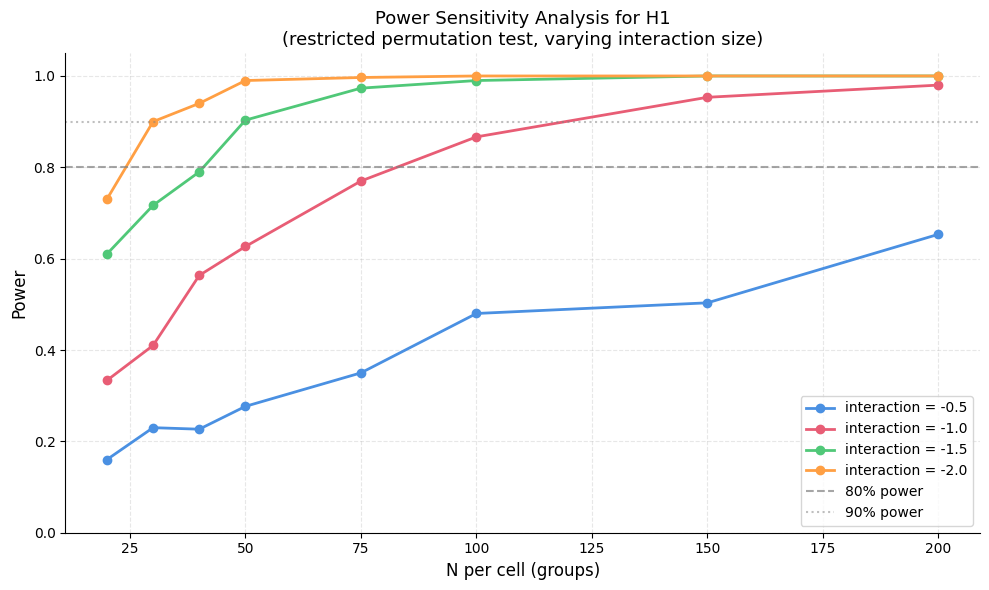

In [45]:
# Plot sensitivity analysis
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#4A90E2", "#E85D75", "#50C878", "#FF9F43"]

for (label, results), color in zip(all_results.items(), colors):
    ns_plot = [r[0] for r in results]
    pwr_plot = [r[1] for r in results]
    ax.plot(ns_plot, pwr_plot, "o-", color=color, linewidth=2, markersize=6, label=label)

ax.axhline(0.80, color="gray", linestyle="--", alpha=0.7, label="80% power")
ax.axhline(0.90, color="gray", linestyle=":", alpha=0.5, label="90% power")
ax.set_xlabel("N per cell (groups)", fontsize=12)
ax.set_ylabel("Power", fontsize=12)
ax.set_title("Power Sensitivity Analysis for H1\n(restricted permutation test, varying interaction size)", fontsize=13)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, alpha=0.3, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


In [46]:
# Minimum detectable interaction size for given sample sizes
# For each N per cell, sweep over interaction sizes and find the smallest
# that gives 80% power.

np.random.seed(321)

def power_for_effect(interaction_size, n_per_cell, 
                     mu_na, mu_ni, sd_sa, sd_na, sd_si, sd_ni,
                     penalty_amb=-1.54, n_sim=300, n_perm=1000, alpha=0.05):
    """Simulate power for a given interaction size and N per cell."""
    penalty_inc = penalty_amb - interaction_size  # interaction = pen_a - pen_i
    mu_sa = mu_na + penalty_amb
    mu_si = mu_ni + penalty_inc
    
    rejections = 0
    for _ in range(n_sim):
        sim_sa = np.clip(np.round(np.random.normal(mu_sa, sd_sa, n_per_cell)), 0, 8)
        sim_na = np.clip(np.round(np.random.normal(mu_na, sd_na, n_per_cell)), 0, 8)
        sim_si = np.clip(np.round(np.random.normal(mu_si, sd_si, n_per_cell)), 0, 8)
        sim_ni = np.clip(np.round(np.random.normal(mu_ni, sd_ni, n_per_cell)), 0, 8)
        
        obs = (sim_sa.mean() - sim_na.mean()) - (sim_si.mean() - sim_ni.mean())
        
        s_comb = np.concatenate([sim_sa, sim_si])
        ns_comb = np.concatenate([sim_na, sim_ni])
        count = 0
        for _ in range(n_perm):
            sp = np.random.permutation(s_comb)
            nsp = np.random.permutation(ns_comb)
            perm_int = (sp[:n_per_cell].mean() - nsp[:n_per_cell].mean()) - \
                       (sp[n_per_cell:].mean() - nsp[n_per_cell:].mean())
            if perm_int <= obs:
                count += 1
        if count / n_perm <= alpha:
            rejections += 1
    return rejections / n_sim

mu_na = conditions["Non-Schema, Ambiguous"].mean()
mu_ni = conditions["Non-Schema, Incompatible"].mean()
sd_sa = conditions["Schema, Ambiguous"].std(ddof=1)
sd_na = conditions["Non-Schema, Ambiguous"].std(ddof=1)
sd_si = conditions["Schema, Incompatible"].std(ddof=1)
sd_ni = conditions["Non-Schema, Incompatible"].std(ddof=1)

# For context
penalty_amb = -1.54
print(f"Schema penalty under ambiguous change: {penalty_amb:.2f}")
print(f"Pooled within-cell SD: {np.sqrt(np.mean([sd_sa**2, sd_na**2, sd_si**2, sd_ni**2])):.2f}")
print(f"\nInteraction sizes tested as fraction of penalty ({penalty_amb:.2f}):")
print()

# Sweep: interaction sizes from -0.25 to -2.5 (in steps of 0.25)
# For N per cell = 30, 40, 50, 60, 80
interaction_sizes = [-0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -2.0, -2.5]
n_options = [30, 40, 50, 60, 80]

print(f"{'Interaction':>12s} {'% of penalty':>12s}", end="")
for n in n_options:
    print(f"  {'N=' + str(n):>6s}", end="")
print()
print("-" * (26 + 8 * len(n_options)))

results_grid = {}
for intx in interaction_sizes:
    pct = intx / penalty_amb * 100
    print(f"{intx:12.2f} {pct:11.0f}%", end="", flush=True)
    results_grid[intx] = {}
    for n in n_options:
        pwr = power_for_effect(intx, n, mu_na, mu_ni, sd_sa, sd_na, sd_si, sd_ni,
                               n_sim=300, n_perm=1000)
        results_grid[intx][n] = pwr
        marker = "*" if pwr >= 0.80 else " "
        print(f"  {pwr:5.3f}{marker}", end="", flush=True)
    print()

print("\n* = >= 80% power")
print(f"\nNote: interaction of -1.54 means the incompatible penalty is fully eliminated")
print(f"      interaction of -0.77 means the incompatible penalty is halved")


Schema penalty under ambiguous change: -1.54
Pooled within-cell SD: 1.82

Interaction sizes tested as fraction of penalty (-1.54):

 Interaction % of penalty    N=30    N=40    N=50    N=60    N=80
------------------------------------------------------------------
       -0.25          16%  0.080   0.110 

KeyboardInterrupt: 

In [ ]:
# Power for H2a: Mann-Whitney U comparing Schema-incompatible vs Schema-ambiguous
# (within Schema groups only)

np.random.seed(456)
n_per_arm_options = [15, 20, 25, 30, 35, 40, 50, 60]

print("Power for H2a: Mann-Whitney U (Schema-incompatible > Schema-ambiguous)")
print(f"Pilot means: Schema-ambiguous={mu_schema_amb:.2f}, Schema-incompatible={mu_schema_inc:.2f}")
print("=" * 60)

power_h2a = []
for n in n_per_arm_options:
    rejections = 0
    for _ in range(n_simulations):
        sim_amb = np.clip(np.round(np.random.normal(mu_schema_amb, sd_schema_amb, n)), 0, 8)
        sim_inc = np.clip(np.round(np.random.normal(mu_schema_inc, sd_schema_inc, n)), 0, 8)
        _, p = stats.mannwhitneyu(sim_amb, sim_inc, alternative="less")
        if p <= alpha:
            rejections += 1
    power = rejections / n_simulations
    power_h2a.append((n, power))
    print(f"  N per arm = {n:3d}  |  power = {power:.3f}")

print(f"\nNote: H2a uses only Schema groups, so N per arm = N per cell from the full design")


Power for H2a: Mann-Whitney U (Schema-incompatible > Schema-ambiguous)
Pilot means: Schema-ambiguous=5.22, Schema-incompatible=5.29
  N per arm =  15  |  power = 0.042
  N per arm =  20  |  power = 0.046
  N per arm =  25  |  power = 0.038
  N per arm =  30  |  power = 0.058
  N per arm =  35  |  power = 0.084
  N per arm =  40  |  power = 0.072
  N per arm =  50  |  power = 0.078
  N per arm =  60  |  power = 0.062

Note: H2a uses only Schema groups, so N per arm = N per cell from the full design


# Pilot Diagnostic: What is the tangrams manipulation actually doing?

The interaction contrast is near zero (~0.02), but the cell means tell the story.

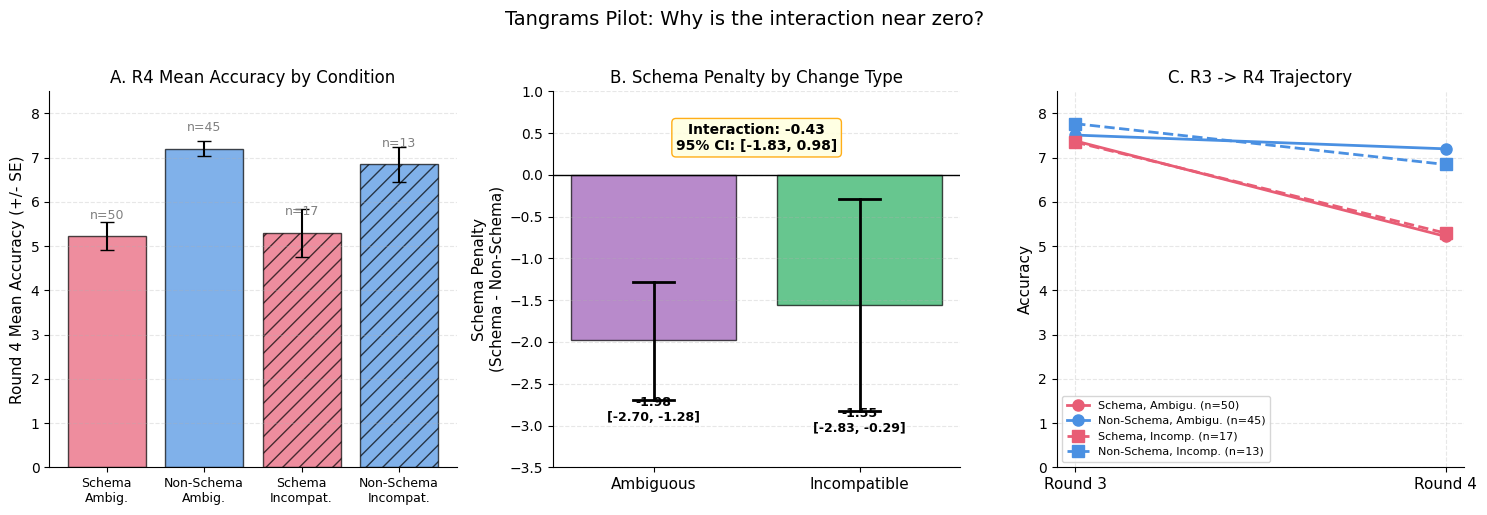


R3 and R4 means by condition:
                                   R3     R4  Delta
--------------------------------------------------
  Schema       Ambiguous   :   7.38   5.22  -2.16
  Non-Schema   Ambiguous   :   7.51   7.20  -0.31
  Schema       Incompatible:   7.35   5.29  -2.06
  Non-Schema   Incompatible:   7.77   6.85  -0.92

Key question: Does the tangrams manipulation affect Schema and Non-Schema groups equally?
  Non-Schema R4: Ambiguous=7.20 vs Incompatible=6.85 (diff=-0.35)
  Schema R4:     Ambiguous=5.22 vs Incompatible=5.29 (diff=+0.07)


In [48]:
# Diagnostic plots for tangrams pilot data
import matplotlib.pyplot as plt
import numpy as np

# Get all 4 conditions, both R3 and R4
conds = {
    ("Schema", "Ambiguous"): data[data["treatment"] == "schema"],
    ("Non-Schema", "Ambiguous"): data[data["treatment"] == "nonschema"],
    ("Schema", "Incompatible"): data[data["treatment"] == "schema_tangrams"],
    ("Non-Schema", "Incompatible"): data[data["treatment"] == "nonschema_tangrams"],
}

# ── Figure 1: Cell means bar chart for R4 accuracy ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel A: R4 accuracy by all 4 cells
ax = axes[0]
labels = ["Schema\nAmbig.", "Non-Schema\nAmbig.", "Schema\nIncompat.", "Non-Schema\nIncompat."]
means = [conds[k]["accuracy_4"].mean() for k in conds]
sds = [conds[k]["accuracy_4"].std(ddof=1) for k in conds]
ns = [len(conds[k]) for k in conds]
ses = [s / np.sqrt(n) for s, n in zip(sds, ns)]
colors = ["#E85D75", "#4A90E2", "#E85D75", "#4A90E2"]
hatches = ["", "", "//", "//"]

bars = ax.bar(range(4), means, yerr=ses, capsize=5, color=colors, alpha=0.7, edgecolor="black")
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)
ax.set_xticks(range(4))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Round 4 Mean Accuracy (+/- SE)", fontsize=11)
ax.set_title("A. R4 Mean Accuracy by Condition", fontsize=12)
ax.set_ylim(0, 8.5)
ax.axhline(y=0, color="black", linewidth=0.5)
for i, (m, n) in enumerate(zip(means, ns)):
    ax.text(i, m + 0.4, f"n={n}", ha="center", fontsize=9, color="gray")
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Panel B: Penalty (Schema - Non-Schema) by change type, with bootstrap CIs
ax = axes[1]

def bootstrap_penalty_ci(schema_vals, nonschema_vals, n_boot=5000, ci=95, seed=42):
    rng = np.random.default_rng(seed)
    boot_penalties = []
    for _ in range(n_boot):
        s_boot = rng.choice(schema_vals, len(schema_vals), replace=True)
        ns_boot = rng.choice(nonschema_vals, len(nonschema_vals), replace=True)
        boot_penalties.append(s_boot.mean() - ns_boot.mean())
    lo = np.percentile(boot_penalties, (100 - ci) / 2)
    hi = np.percentile(boot_penalties, 100 - (100 - ci) / 2)
    return np.array(boot_penalties), lo, hi

s_amb = conds[("Schema", "Ambiguous")]["accuracy_4"].values
ns_amb = conds[("Non-Schema", "Ambiguous")]["accuracy_4"].values
s_inc = conds[("Schema", "Incompatible")]["accuracy_4"].values
ns_inc = conds[("Non-Schema", "Incompatible")]["accuracy_4"].values

penalty_amb = s_amb.mean() - ns_amb.mean()
penalty_inc = s_inc.mean() - ns_inc.mean()
interaction = penalty_amb - penalty_inc

_, ci_amb_lo, ci_amb_hi = bootstrap_penalty_ci(s_amb, ns_amb)
_, ci_inc_lo, ci_inc_hi = bootstrap_penalty_ci(s_inc, ns_inc)

# Bootstrap CI for the interaction itself
rng = np.random.default_rng(42)
boot_interactions = []
for _ in range(5000):
    b_sa = rng.choice(s_amb, len(s_amb), replace=True)
    b_na = rng.choice(ns_amb, len(ns_amb), replace=True)
    b_si = rng.choice(s_inc, len(s_inc), replace=True)
    b_ni = rng.choice(ns_inc, len(ns_inc), replace=True)
    boot_interactions.append((b_sa.mean() - b_na.mean()) - (b_si.mean() - b_ni.mean()))
ci_int_lo = np.percentile(boot_interactions, 2.5)
ci_int_hi = np.percentile(boot_interactions, 97.5)

bar_colors = ["#9B59B6", "#27AE60"]
bars_b = ax.bar([0, 1], [penalty_amb, penalty_inc], color=bar_colors, alpha=0.7, edgecolor="black")

# Error bars for penalty CIs
ax.plot([0, 0], [ci_amb_lo, ci_amb_hi], color="black", linewidth=2, zorder=5)
ax.plot([-0.1, 0.1], [ci_amb_lo, ci_amb_lo], color="black", linewidth=2, zorder=5)
ax.plot([-0.1, 0.1], [ci_amb_hi, ci_amb_hi], color="black", linewidth=2, zorder=5)

ax.plot([1, 1], [ci_inc_lo, ci_inc_hi], color="black", linewidth=2, zorder=5)
ax.plot([0.9, 1.1], [ci_inc_lo, ci_inc_lo], color="black", linewidth=2, zorder=5)
ax.plot([0.9, 1.1], [ci_inc_hi, ci_inc_hi], color="black", linewidth=2, zorder=5)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Ambiguous", "Incompatible"], fontsize=11)
ax.set_ylabel("Schema Penalty\n(Schema - Non-Schema)", fontsize=11)
ax.set_title("B. Schema Penalty by Change Type", fontsize=12)
ax.axhline(y=0, color="black", linewidth=1)

# Label penalties
for i, (p, lo, hi) in enumerate([(penalty_amb, ci_amb_lo, ci_amb_hi), 
                                   (penalty_inc, ci_inc_lo, ci_inc_hi)]):
    ax.text(i, min(lo, p) - 0.25, f"{p:.2f}\n[{lo:.2f}, {hi:.2f}]", 
            ha="center", fontsize=9, fontweight="bold")

# Interaction annotation
ax.text(0.5, 0.3, f"Interaction: {interaction:.2f}\n95% CI: [{ci_int_lo:.2f}, {ci_int_hi:.2f}]",
        ha="center", fontsize=10, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="orange", alpha=0.9))

ax.set_ylim(-3.5, 1.0)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Panel C: R3 vs R4 accuracy (trajectory) by condition
ax = axes[2]
style = {
    ("Schema", "Ambiguous"): ("#E85D75", "-", "o"),
    ("Non-Schema", "Ambiguous"): ("#4A90E2", "-", "o"),
    ("Schema", "Incompatible"): ("#E85D75", "--", "s"),
    ("Non-Schema", "Incompatible"): ("#4A90E2", "--", "s"),
}
for key, df in conds.items():
    color, ls, marker = style[key]
    r3_mean = df["accuracy_3"].mean()
    r4_mean = df["accuracy_4"].mean()
    label = f"{key[0]}, {key[1][:6]}. (n={len(df)})"
    ax.plot([3, 4], [r3_mean, r4_mean], marker=marker, linestyle=ls,
            color=color, linewidth=2, markersize=8, label=label)

ax.set_xticks([3, 4])
ax.set_xticklabels(["Round 3", "Round 4"], fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_title("C. R3 -> R4 Trajectory", fontsize=12)
ax.set_ylim(0, 8.5)
ax.legend(fontsize=8, loc="lower left")
ax.grid(True, alpha=0.3, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.suptitle("Tangrams Pilot: Why is the interaction near zero?", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print the key comparison
print("\nR3 and R4 means by condition:")
print(f"{'':30s} {'R3':>6s} {'R4':>6s} {'Delta':>6s}")
print("-" * 50)
for key, df in conds.items():
    r3 = df["accuracy_3"].mean()
    r4 = df["accuracy_4"].mean()
    delta = r4 - r3
    print(f"  {key[0]:12s} {key[1]:12s}: {r3:6.2f} {r4:6.2f} {delta:+6.2f}")

print(f"\nKey question: Does the tangrams manipulation affect Schema and Non-Schema groups equally?")
print(f"  Non-Schema R4: Ambiguous={ns_amb.mean():.2f} vs Incompatible={ns_inc.mean():.2f} (diff={ns_inc.mean() - ns_amb.mean():+.2f})")
print(f"  Schema R4:     Ambiguous={s_amb.mean():.2f} vs Incompatible={s_inc.mean():.2f} (diff={s_inc.mean() - s_amb.mean():+.2f})")



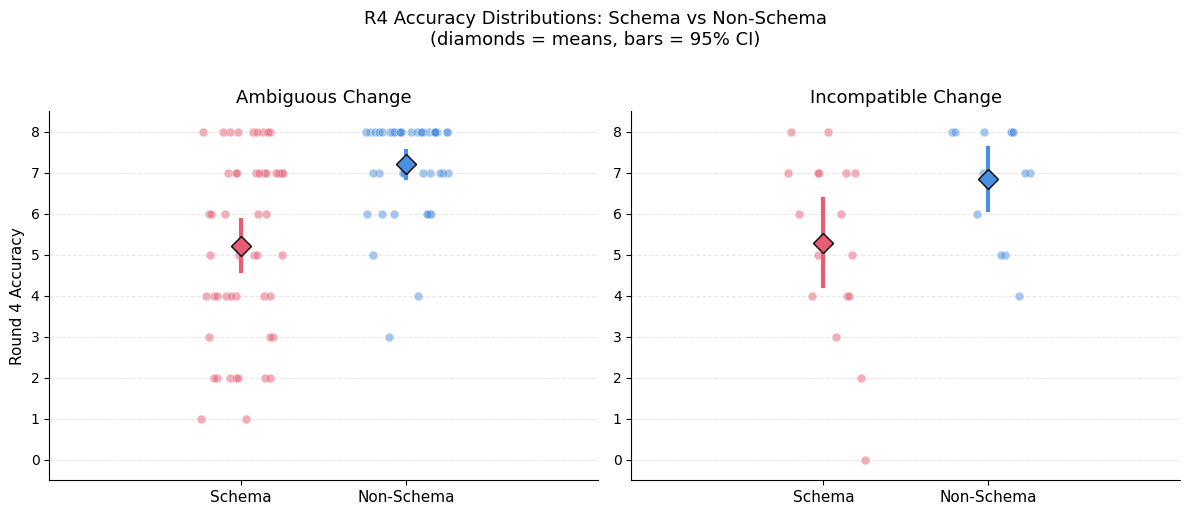

In [43]:
# Distribution comparison: is the variance structure different?
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, change_type in zip(axes, ["Ambiguous", "Incompatible"]):
    for schema_cond, color, offset in [("Schema", "#E85D75", -0.15), ("Non-Schema", "#4A90E2", 0.15)]:
        vals = conds[(schema_cond, change_type)]["accuracy_4"].values
        n = len(vals)
        # Jittered strip plot
        jitter = np.random.default_rng(42).uniform(-0.08, 0.08, n)
        x_pos = np.array([0 + offset] * n) + jitter
        ax.scatter(x_pos, vals, alpha=0.5, color=color, s=40, edgecolors="white", linewidth=0.5)
        # Mean + CI
        mean = vals.mean()
        se = vals.std(ddof=1) / np.sqrt(n)
        ax.plot(offset, mean, "D", color=color, markersize=10, zorder=5, markeredgecolor="black")
        ax.plot([offset, offset], [mean - 1.96*se, mean + 1.96*se], "-", color=color, linewidth=3, zorder=4)
    
    ax.set_xlim(-0.5, 0.5)
    ax.set_xticks([-0.15, 0.15])
    ax.set_xticklabels(["Schema", "Non-Schema"], fontsize=11)
    ax.set_ylim(-0.5, 8.5)
    ax.set_yticks(range(0, 9))
    ax.set_ylabel("Round 4 Accuracy" if ax == axes[0] else "", fontsize=11)
    ax.set_title(f"{change_type} Change", fontsize=13)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("R4 Accuracy Distributions: Schema vs Non-Schema\n(diamonds = means, bars = 95% CI)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()



# T-tests

In [17]:
# Quick look for sanity
data.groupby("treatment")[["accuracy_3", "accuracy_4", "time_labeling_3", "time_labeling_4", "score_3", "score_4"]].mean().loc[['nonschema', 'schema']]

,accuracy_3,accuracy_4,time_labeling_3,time_labeling_4,score_3,score_4
treatment,,,,,,
nonschema,6.696970,6.545455,183.247364,176.963182,2.648491,2.647041
schema,7.411765,5.294118,113.126235,217.136824,5.983960,3.039279


In [18]:
# === Preregistered Primary Analyses ===
# H1: Round 3 labeling time (max per group), one-tailed Welch's t-test (Schema < Nonschema)
# H2a/H2b: Round 4 accuracy (unique matched recall), one-tailed Mann–Whitney U (Schema < Nonschema)

# Prepare data for H1 and H2a/H2b
schema = data[data["treatment"] == "schema"]
nonschema = data[data["treatment"] == "nonschema"]

# H1: Round 3 labeling time (max per group)
schema_time3 = schema["time_labeling_3"].values
nonschema_time3 = nonschema["time_labeling_3"].values

t_stat, p_val = stats.ttest_ind(schema_time3, nonschema_time3, equal_var=False, alternative="less")
mean_diff = schema_time3.mean() - nonschema_time3.mean()
ci = stats.t.interval(
    0.95, 
    df=min(len(schema_time3), len(nonschema_time3))-1, 
    loc=mean_diff, 
    scale=np.sqrt(schema_time3.var(ddof=1)/len(schema_time3) + nonschema_time3.var(ddof=1)/len(nonschema_time3))
)
pooled_sd = np.sqrt(((len(schema_time3)-1)*schema_time3.var(ddof=1) + (len(nonschema_time3)-1)*nonschema_time3.var(ddof=1)) / (len(schema_time3)+len(nonschema_time3)-2))
cohens_d = mean_diff / pooled_sd

print("="*60)
print("H1: Round 3 Labeling Time (max per group)")
print("="*60)
print(f"Schema n={len(schema_time3)}, mean={schema_time3.mean():.2f}, sd={schema_time3.std(ddof=1):.2f}")
print(f"Nonschema n={len(nonschema_time3)}, mean={nonschema_time3.mean():.2f}, sd={nonschema_time3.std(ddof=1):.2f}")
print(f"Mean difference (Schema - Nonschema): {mean_diff:.2f} sec")
print(f"95% CI for mean difference: [{ci[0]:.2f}, {ci[1]:.2f}]")  # TODO: make the CI calculation one-sided to match the t-test
print(f"Welch's t-test (one-tailed, Schema < Nonschema): t={t_stat:.3f}, p={p_val:.5f}")
print(f"Cohen's d: {cohens_d:.3f}\n")

H1: Round 3 Labeling Time (max per group)
Schema n=34, mean=113.13, sd=62.15
Nonschema n=33, mean=183.25, sd=64.15
Mean difference (Schema - Nonschema): -70.12 sec
95% CI for mean difference: [-101.57, -38.67]
Welch's t-test (one-tailed, Schema < Nonschema): t=-4.542, p=0.00001
Cohen's d: -1.110



In [19]:
# H2a/H2b: Round 4 accuracy — all preregistered reported quantities
# Group medians, Hodges-Lehmann estimate with 95% CI,
# Cliff's delta, and permutation-based one-sided Mann-Whitney U p-value.

np.random.seed(42)

schema_points4 = schema["accuracy_4"].values
nonschema_points4 = nonschema["accuracy_4"].values

# Group means and medians
schema_mean4 = np.mean(schema_points4)
nonschema_mean4 = np.mean(nonschema_points4)
schema_median4 = np.median(schema_points4)
nonschema_median4 = np.median(nonschema_points4)

# Hodges-Lehmann estimate and 95% bootstrap CI
pairwise_diffs = schema_points4[:, np.newaxis] - nonschema_points4
hl_estimate = np.median(pairwise_diffs)

n_bootstrap = 9999
boot_hl = []
for _ in range(n_bootstrap):
    b_schema = np.random.choice(schema_points4, len(schema_points4), replace=True)
    b_nonschema = np.random.choice(nonschema_points4, len(nonschema_points4), replace=True)
    boot_hl.append(np.median(b_schema[:, np.newaxis] - b_nonschema))
hl_ci = np.percentile(boot_hl, [2.5, 97.5])

# Cliff's delta
def cliffs_delta(x, y):
    n1, n2 = len(x), len(y)
    greater = np.sum(x[:, np.newaxis] > y)
    less = np.sum(x[:, np.newaxis] < y)
    return (greater - less) / (n1 * n2)

cliff_d = cliffs_delta(schema_points4, nonschema_points4)

# Permutation-based Mann-Whitney U p-value
observed_u, _ = stats.mannwhitneyu(schema_points4, nonschema_points4, alternative='less')
combined = np.concatenate([schema_points4, nonschema_points4])
n_schema = len(schema_points4)

perm_u_stats = np.array([
    stats.mannwhitneyu(
        (perm := np.random.permutation(combined))[:n_schema],
        perm[n_schema:],
        alternative='less'
    ).statistic
    for _ in range(9999)
])
p_perm = (np.sum(perm_u_stats <= observed_u) + 1) / (9999 + 1)

# Report
print("=" * 60)
print("H2a/H2b: Round 4 Accuracy (# correct out of 8)")
print("=" * 60)
print(f"Schema:    n={len(schema_points4)}, mean={schema_mean4:.2f}, median={schema_median4:.1f}")
print(f"Nonschema: n={len(nonschema_points4)}, mean={nonschema_mean4:.2f}, median={nonschema_median4:.1f}")
print(f"Hodges-Lehmann estimate (Schema − Nonschema): {hl_estimate:.2f}")
print(f"95% bootstrap CI: [{hl_ci[0]:.2f}, {hl_ci[1]:.2f}]")
print(f"Cliff's delta: {cliff_d:.3f}")
print(f"Mann-Whitney U (one-tailed, Schema < Nonschema): U={observed_u:.1f}, p={p_perm:.4f}")
print(f"(permutation-based, 9999 permutations, seed=42)")

H2a/H2b: Round 4 Accuracy (# correct out of 8)
Schema:    n=34, mean=5.29, median=6.0
Nonschema: n=33, mean=6.55, median=7.0
Hodges-Lehmann estimate (Schema − Nonschema): -1.00
95% bootstrap CI: [-3.00, 0.00]
Cliff's delta: -0.354
Mann-Whitney U (one-tailed, Schema < Nonschema): U=362.5, p=0.0050
(permutation-based, 9999 permutations, seed=42)


2. BOOTSTRAP CI FOR MEAN DIFFERENCE (Round 4 Accuracy)
Mean difference (schema - nonschema): -1.25
95% Bootstrap CI: [-2.34, -0.12]
CI includes 0? False



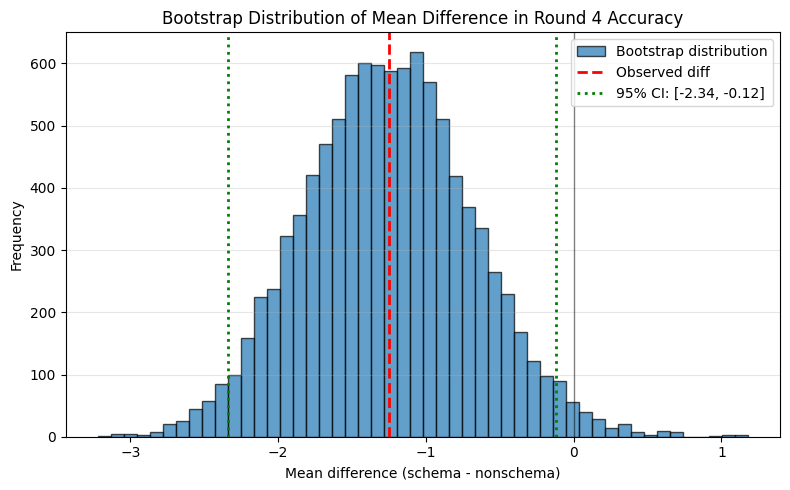

In [20]:
# 2. BOOTSTRAP CI FOR MEAN DIFFERENCE (nonparametric, 95% CI)
# Resample pairs within each treatment; compute difference in means

def bootstrap_ci(group1, group2, n_bootstrap=10000, ci=95):
    """
    Bootstrap CI for difference in means (group1 - group2).
    Resamples independently within each group.
    """
    alpha_level = (100 - ci) / 2
    boot_diffs = []
    np.random.seed(42)
    
    for _ in range(n_bootstrap):
        boot_g1 = np.random.choice(group1, size=len(group1), replace=True)
        boot_g2 = np.random.choice(group2, size=len(group2), replace=True)
        boot_diffs.append(boot_g1.mean() - boot_g2.mean())
    
    boot_diffs = np.array(boot_diffs)
    ci_lower = np.percentile(boot_diffs, alpha_level)
    ci_upper = np.percentile(boot_diffs, 100 - alpha_level)
    
    return boot_diffs, ci_lower, ci_upper

boot_diffs, ci_lower, ci_upper = bootstrap_ci(
    schema_points4, nonschema_points4, n_bootstrap=10000, ci=95
)

print("=" * 60)
print("2. BOOTSTRAP CI FOR MEAN DIFFERENCE (Round 4 Accuracy)")
print("=" * 60)
print(f"Mean difference (schema - nonschema): {schema_points4.mean() - nonschema_points4.mean():.2f}")
print(f"95% Bootstrap CI: [{ci_lower:.2f}, {ci_upper:.2f}]")
print(f"CI includes 0? {ci_lower <= 0 <= ci_upper}\n")

# Plot bootstrap distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(boot_diffs, bins=50, alpha=0.7, edgecolor='black', label='Bootstrap distribution')
ax.axvline(schema_points4.mean() - nonschema_points4.mean(), color='red', linestyle='--', linewidth=2, label='Observed diff')
ax.axvline(ci_lower, color='green', linestyle=':', linewidth=2, label=f'95% CI: [{ci_lower:.2f}, {ci_upper:.2f}]')
ax.axvline(ci_upper, color='green', linestyle=':', linewidth=2)
ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax.set_xlabel('Mean difference (schema - nonschema)')
ax.set_ylabel('Frequency')
ax.set_title('Bootstrap Distribution of Mean Difference in Round 4 Accuracy')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


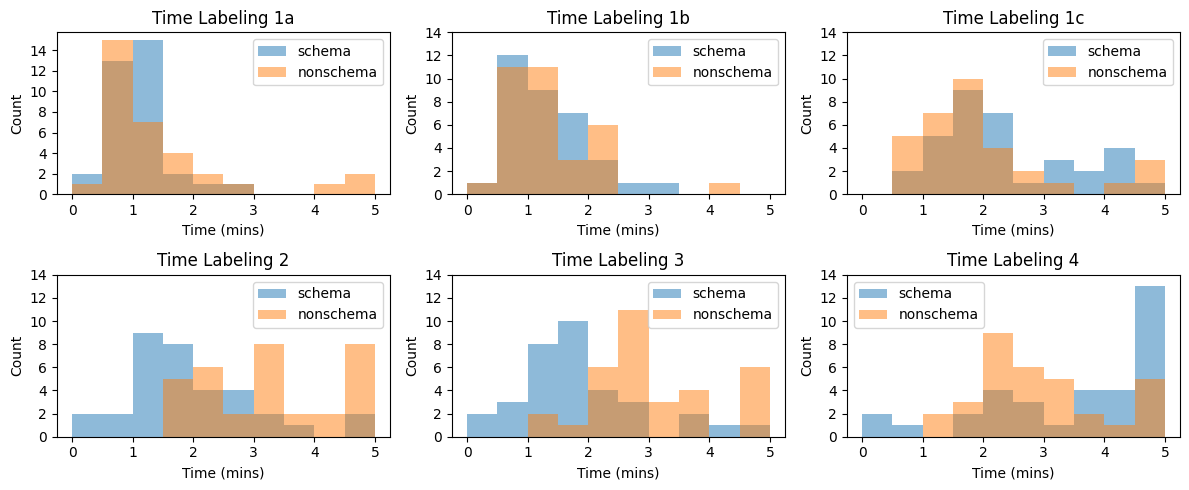

In [21]:

# plot a histogram of completion times by stage and treatment
plt.figure(figsize=(12, 5))
for i, stage in enumerate(["1a", "1b", "1c", "2", "3", "4"]):
    plt.subplot(2, 3, i+1)
    for treatment in ["schema", "nonschema"]:
        subset = data[data["treatment"] == treatment]
        plt.hist(subset[f"time_labeling_{stage}"], alpha=0.5, label=treatment, bins=range(0, 310, 30))

    plt.title(f"Time Labeling {stage}")
    plt.xlabel("Time (mins)")
    plt.ylabel("Count")
    plt.legend()
    plt.yticks(range(0,15,2))
    plt.xticks(range(0, 330, 60), range(0, 6, 1))

plt.tight_layout()

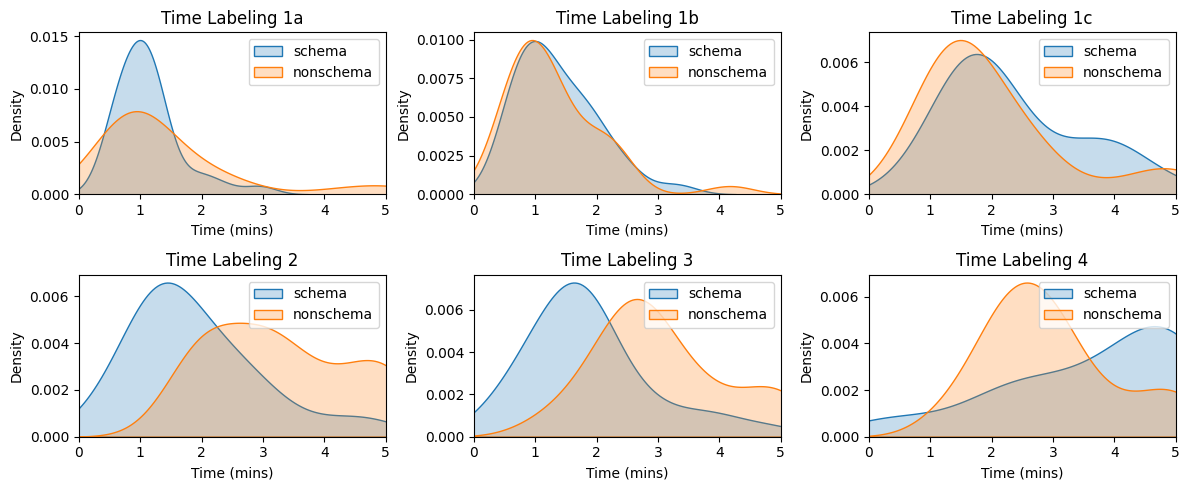

In [22]:
# plot kde desnsity of completion times by stage and treatment
plt.figure(figsize=(12, 5))
for i, stage in enumerate(["1a", "1b", "1c", "2", "3", "4"]):
    plt.subplot(2, 3, i+1)
    for treatment in ["schema", "nonschema"]:
        subset = data[data["treatment"] == treatment]
        sns.kdeplot(subset[f"time_labeling_{stage}"], label=treatment, fill=True)
    plt.title(f"Time Labeling {stage}")
    plt.xlabel("Time (mins)")
    plt.ylabel("Density")
    plt.xticks(range(0, 330, 60), range(0, 6, 1))
    plt.legend()
    plt.xlim(0, 300)
plt.tight_layout()

# Plots

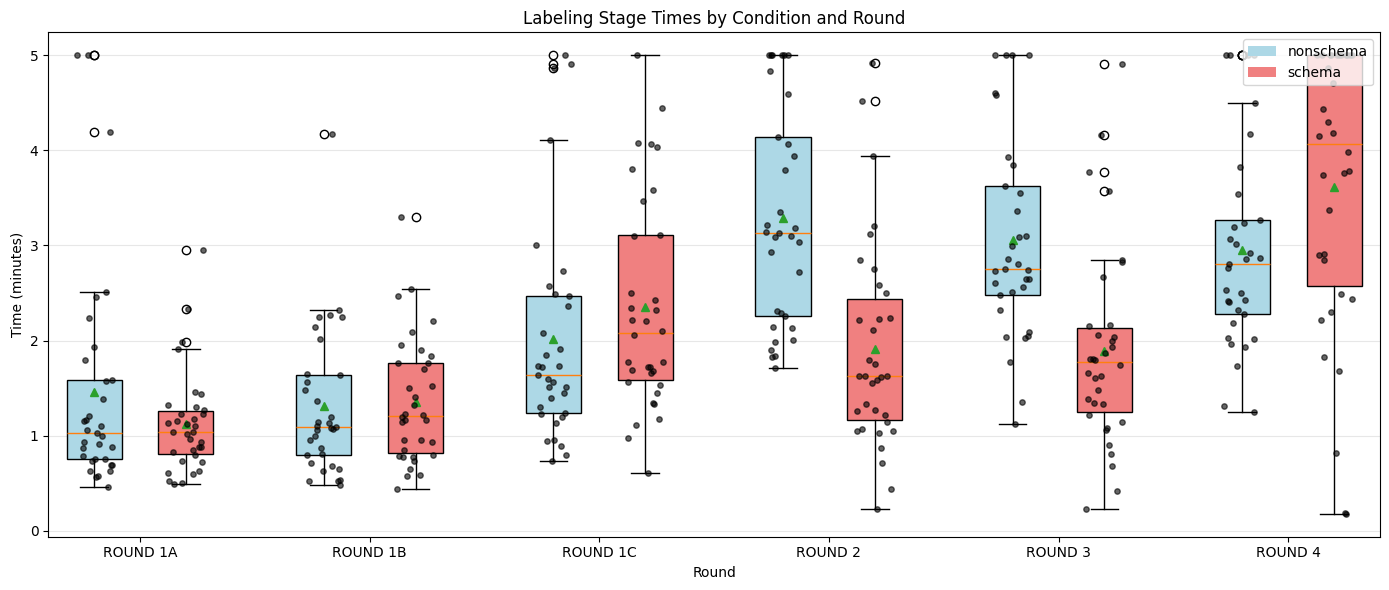

In [23]:
labeling_stage_time_cols = [col for col in data.columns if col.startswith("time_labeling_")]


# Prepare data for box plot
# Melt the data to long format for easier plotting
plot_data = []
for col in labeling_stage_time_cols:
    for idx, row in data.iterrows():
        plot_data.append({
                'round': col,
                'time': row[col],
                'condition': row['treatment']
            })

plot_df = pd.DataFrame(plot_data)

# Create the box plot
fig, ax = plt.subplots(figsize=(14, 6))

# Get unique rounds and conditions
rounds = labeling_stage_time_cols  # Use original column order
conditions = sorted(plot_df['condition'].unique())

def prettify_label(col_name):
    # Convert 'labeling_1a' to 'Round 1a', etc.
    return col_name.replace('time_labeling_', 'Round ').upper()

positions = []
labels = []
colors = []
color_map = {'nonschema': 'lightblue', 'schema': 'lightcoral'}

for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        positions.append(i * (len(conditions) + 0.5) + j)
        if j == 0:
            labels.append(prettify_label(round_name))
        colors.append(color_map.get(condition, 'gray'))

# Prepare data for each box
box_data = []
for round_name in rounds:
    for condition in conditions:
        data_subset = plot_df[(plot_df['round'] == round_name) & \
                              (plot_df['condition'] == condition)]['time'].dropna()
        box_data.append(data_subset)

# Create box plot
bp = ax.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,
                showmeans=True, meanline=False)

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Set x-axis labels
ax.set_xticks([i * (len(conditions) + 0.5) + 0.5 for i in range(len(rounds))])
ax.set_xticklabels([prettify_label(round_name) for round_name in rounds])

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[cond], label=cond) 
                   for cond in conditions]
ax.legend(handles=legend_elements, loc='upper right')

# Labels and title
ax.set_xlabel('Round')
ax.set_ylabel('Time (minutes)')
ax.set_title('Labeling Stage Times by Condition and Round')
ax.grid(axis='y', alpha=0.3)

# # Add n labels above each box
# n_counts = plot_df.groupby(['round', 'condition']).count()['time']
# for i, round_name in enumerate(rounds):
#     for j, condition in enumerate(conditions):
#         n = n_counts.get((round_name, condition), 0)
#         pos = i * (len(conditions) + 0.5) + j
#         y = box_data[i * len(conditions) + j].median() if len(box_data[i * len(conditions) + j]) > 0 else 0
#         ax.text(pos, y, f'n={n}', ha='center', va='bottom', fontsize=10, color='black', rotation=0)

# add raw points
for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        pos = i * (len(conditions) + 0.5) + j
        data_subset = box_data[i * len(conditions) + j]
        # Add jittered scatter points
        x_jitter = np.random.uniform(-0.2, 0.2, size=len(data_subset))
        ax.scatter(np.full(len(data_subset), pos) + x_jitter, data_subset, 
                   alpha=0.6, color='black', s=15, zorder=3)

ax.set_yticks(range(0, 310, 60))
ax.set_yticklabels(range(0, 6, 1))

plt.tight_layout()
plt.show()

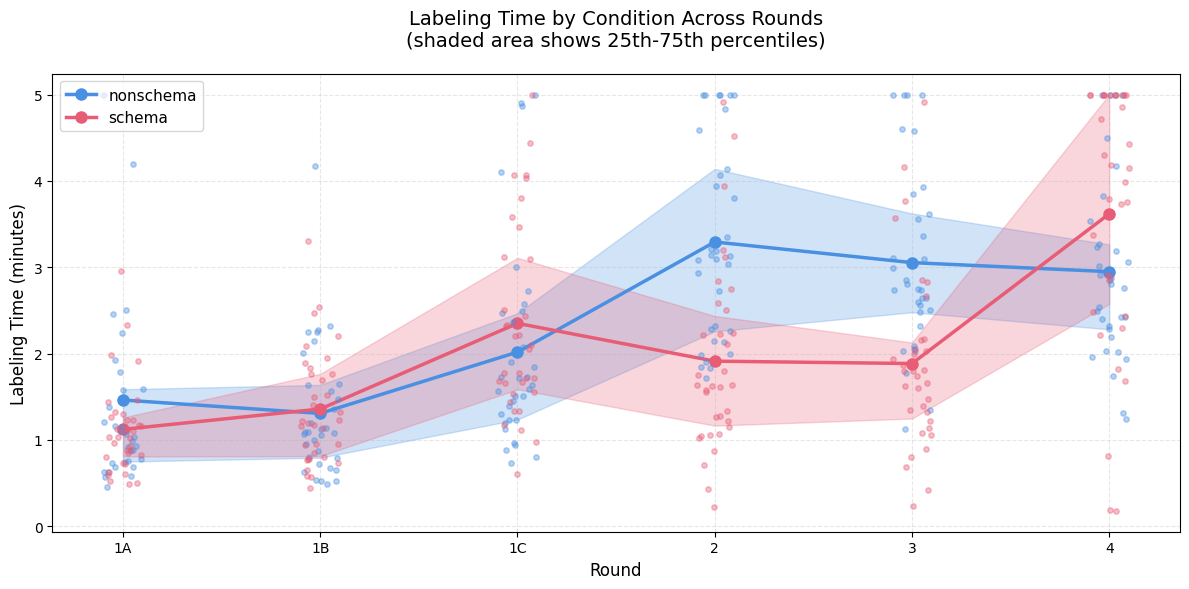

In [24]:
# Shaded area plot of labeling time condition and round
labeling_stage_time_cols = [col for col in data.columns if col.startswith("time_labeling_")]

# Prepare data for plotting
plot_data = []
for col in labeling_stage_time_cols:
    for idx, row in data.iterrows():
        plot_data.append({
                'round': col,
                'time': row[col],
                'condition': row['treatment']
            })

plot_df = pd.DataFrame(plot_data)

# Extract round labels for x-axis (e.g., 'time_labeling_1a' -> '1a')
def extract_round_label(col_name):
    return col_name.replace('time_labeling_', '').upper()

# Calculate statistics by condition and round
fig, ax = plt.subplots(figsize=(12, 6))

color_map = {'nonschema': '#4A90E2', 'schema': '#E85D75'}  # Darker colors for lines
fill_alpha = 0.25

# Create x-axis positions for each round
round_labels = [extract_round_label(col) for col in labeling_stage_time_cols]
x_positions = list(range(len(labeling_stage_time_cols)))

for condition in ['nonschema', 'schema']:
    # Calculate mean and percentiles for each round
    x_vals = []
    means = []
    q25s = []
    q75s = []
    
    for idx, col in enumerate(labeling_stage_time_cols):
        condition_data = plot_df[(plot_df['round'] == col) & 
                                  (plot_df['condition'] == condition)]['time'].dropna()
        
        if len(condition_data) > 0:
            x_vals.append(idx)
            means.append(condition_data.mean())
            q25s.append(condition_data.quantile(0.25))
            q75s.append(condition_data.quantile(0.75))
    
    # Plot the mean line
    ax.plot(x_vals, means, marker='o', linewidth=2.5, 
            label=condition, color=color_map[condition], markersize=8)
    
    # Add shaded area for IQR (25th-75th percentiles)
    ax.fill_between(x_vals, q25s, q75s, alpha=fill_alpha, 
                     color=color_map[condition])



# add raw points
for condition in ['nonschema', 'schema']:
    for idx, col in enumerate(labeling_stage_time_cols):
        condition_data = plot_df[(plot_df['round'] == col) & 
                                  (plot_df['condition'] == condition)]['time'].dropna()
        if len(condition_data) > 0:
            x_jitter = np.random.uniform(-0.1, 0.1, size=len(condition_data))
            ax.scatter(np.full(len(condition_data), idx) + x_jitter, condition_data, 
                       alpha=0.4, color=color_map[condition], s=15, zorder=3)

# Formatting
ax.set_xlabel('Round', fontsize=12)
ax.set_ylabel('Labeling Time (minutes)', fontsize=12)
ax.set_title('Labeling Time by Condition Across Rounds\n(shaded area shows 25th-75th percentiles)', 
             fontsize=14, pad=20)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xticks(x_positions)
ax.set_xticklabels(round_labels)
ax.set_yticks(range(0, 310, 60))
ax.set_yticklabels(range(0, 6, 1))

plt.tight_layout()
plt.show()


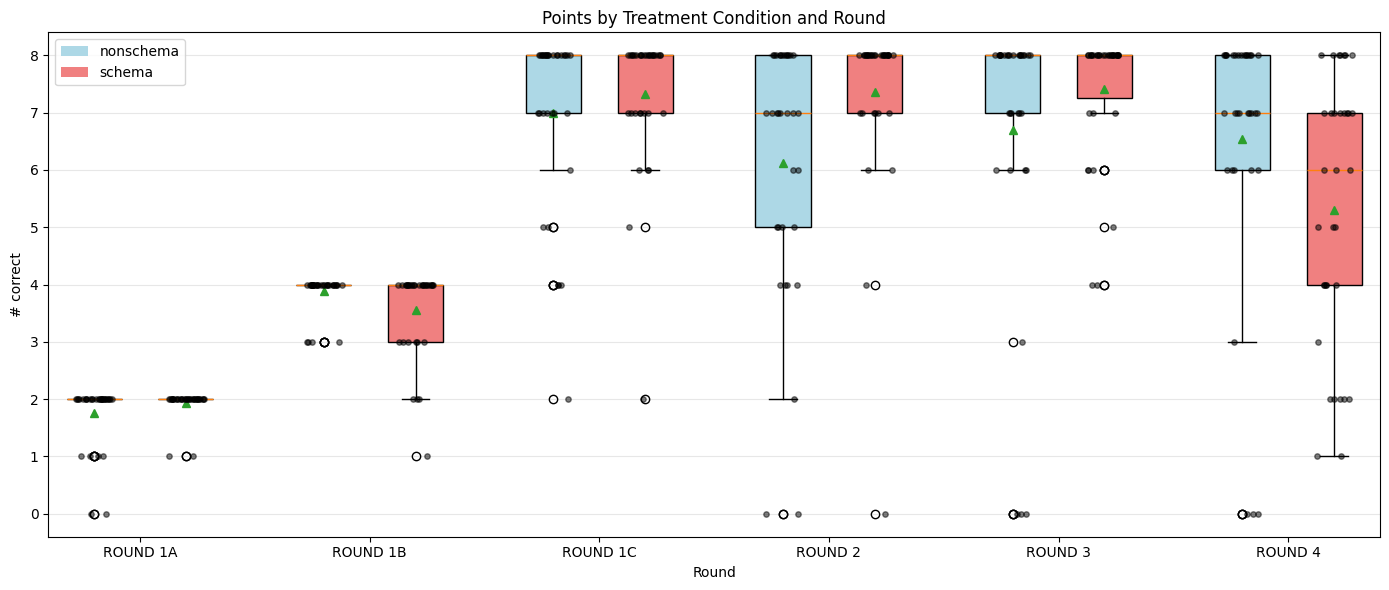

In [25]:
# Plot points by round instead of labeling time
acc_cols = [col for col in data.columns if col.startswith("accuracy_")]


# Prepare data for box plot
plot_data = []
for col in acc_cols:
    for idx, row in data.iterrows():
        plot_data.append({
                'round': col,
                'accuracy': row[col],
                'condition': row['treatment']
            })

plot_df = pd.DataFrame(plot_data)

# Create the box plot
fig, ax = plt.subplots(figsize=(14, 6))

# Get unique rounds and conditions
rounds = acc_cols  # Use original column order
conditions = sorted(plot_df['condition'].unique())

def prettify_label(col_name):
    # Convert 'points_1a' to 'Round 1a', etc.
    return col_name.replace('accuracy_', 'Round ').upper()

positions = []
labels = []
colors = []
color_map = {'nonschema': 'lightblue', 'schema': 'lightcoral'}

for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        positions.append(i * (len(conditions) + 0.5) + j)
        if j == 0:
            labels.append(prettify_label(round_name))
        colors.append(color_map.get(condition, 'gray'))

# Prepare data for each box
box_data = []
for round_name in rounds:
    for condition in conditions:
        data_subset = plot_df[(plot_df['round'] == round_name) & \
                              (plot_df['condition'] == condition)]['accuracy'].dropna()
        box_data.append(data_subset)

# Create box plot
bp = ax.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,
                showmeans=True, meanline=False)

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Set x-axis labels
ax.set_xticks([i * (len(conditions) + 0.5) + 0.5 for i in range(len(rounds))])
ax.set_xticklabels([prettify_label(round_name) for round_name in rounds])

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[cond], label=cond) 
                   for cond in conditions]
ax.legend(handles=legend_elements, loc='upper left')

# Labels and title
ax.set_xlabel('Round')
ax.set_ylabel('# correct')
ax.set_title('Points by Treatment Condition and Round')
ax.grid(axis='y', alpha=0.3)

# # Add n labels above each box
# n_counts = plot_df.groupby(['round', 'condition']).count()['accuracy']
# for i, round_name in enumerate(rounds):
#     for j, condition in enumerate(conditions):
#         n = n_counts.get((round_name, condition), 0)
#         pos = i * (len(conditions) + 0.5) + j
#         y = box_data[i * len(conditions) + j].median() if len(box_data[i * len(conditions) + j]) > 0 else 0
#         ax.text(pos, y, f'n={n}', ha='center', va='bottom', fontsize=10, color='black', rotation=0)


# add raw points
for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        pos = i * (len(conditions) + 0.5) + j
        data_subset = box_data[i * len(conditions) + j]
        # Add jittered scatter points
        x_jitter = np.random.uniform(-0.2, 0.2, size=len(data_subset))
        ax.scatter(np.full(len(data_subset), pos) + x_jitter, data_subset, 
                   alpha=0.5, color='black', s=15, zorder=3)

plt.tight_layout()
plt.show()

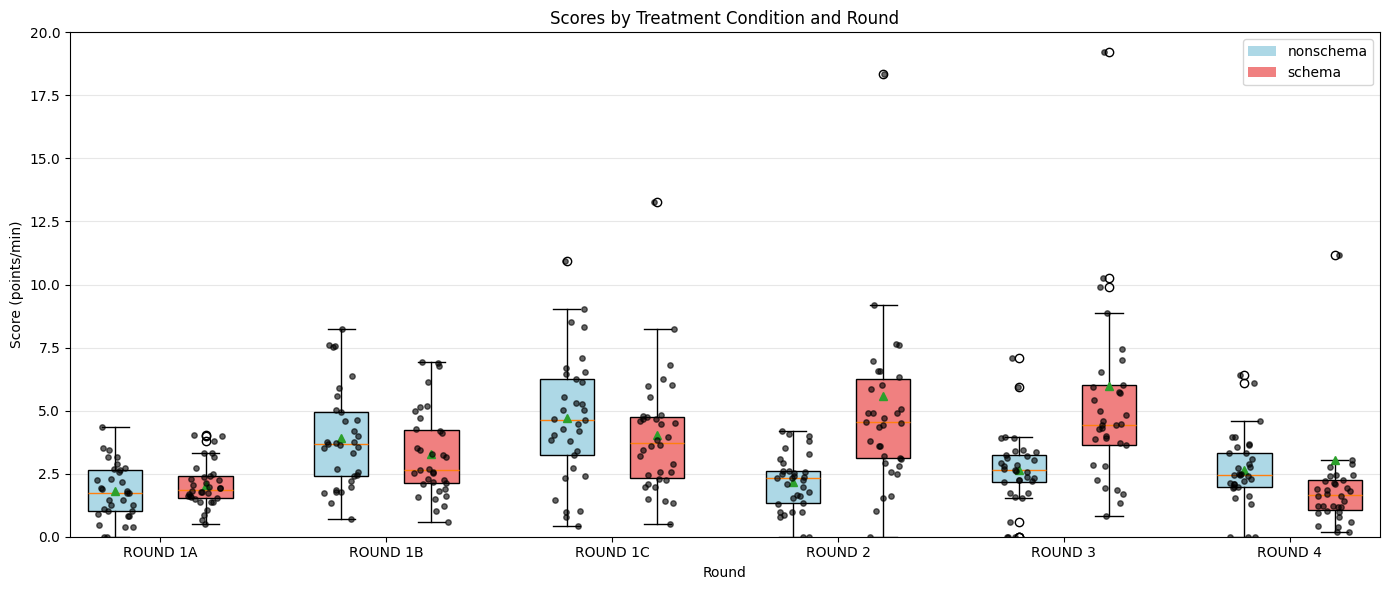

In [26]:
# Plot scores by round instead of labeling time
score_cols = [col for col in data.columns if col.startswith('score_')]



# Prepare data for box plot
plot_data = []
for col in score_cols:
    for idx, row in data.iterrows():
        plot_data.append({
                'round': col,
                'score': row[col],
                'condition': row['treatment']
            })

plot_df = pd.DataFrame(plot_data)

# Create the box plot
fig, ax = plt.subplots(figsize=(14, 6))

# Get unique rounds and conditions
rounds = score_cols  # Use original column order
conditions = sorted(plot_df['condition'].unique())

def prettify_label(col_name):
    # Convert 'score_1a' to 'Round 1a', etc.
    return col_name.replace('score_', 'Round ').upper()

positions = []
labels = []
colors = []
color_map = {'nonschema': 'lightblue', 'schema': 'lightcoral'}

for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        positions.append(i * (len(conditions) + 0.5) + j)
        if j == 0:
            labels.append(prettify_label(round_name))
        colors.append(color_map.get(condition, 'gray'))

box_data = []
for round_name in rounds:
    for condition in conditions:
        data_subset = plot_df[(plot_df['round'] == round_name) & \
                              (plot_df['condition'] == condition)]['score'].dropna()
        box_data.append(data_subset)

bp = ax.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,
                showmeans=True, meanline=False)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_xticks([i * (len(conditions) + 0.5) + 0.5 for i in range(len(rounds))])
ax.set_xticklabels([prettify_label(round_name) for round_name in rounds])

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[cond], label=cond) 
                   for cond in conditions]
ax.legend(handles=legend_elements, loc='upper right')

ax.set_xlabel('Round')
ax.set_ylabel('Score (points/min)')
ax.set_title('Scores by Treatment Condition and Round')
ax.grid(axis='y', alpha=0.3)

# # Add n labels above each box
# n_counts = plot_df.groupby(['round', 'condition']).count()['score']
# for i, round_name in enumerate(rounds):
#     for j, condition in enumerate(conditions):
#         n = n_counts.get((round_name, condition), 0)
#         pos = i * (len(conditions) + 0.5) + j
#         y = box_data[i * len(conditions) + j].median() if len(box_data[i * len(conditions) + j]) > 0 else 0
#         ax.text(pos, y, f'n={n}', ha='center', va='bottom', fontsize=10, color='black', rotation=0)

# add raw points
for i, round_name in enumerate(rounds):
    for j, condition in enumerate(conditions):
        pos = i * (len(conditions) + 0.5) + j
        data_subset = box_data[i * len(conditions) + j]
        # Add jittered scatter points
        x_jitter = np.random.uniform(-0.2, 0.2, size=len(data_subset))
        ax.scatter(np.full(len(data_subset), pos) + x_jitter, data_subset, 
                   alpha=0.6, color='black', s=15, zorder=3)

ax.set_ylim(0,20)

plt.tight_layout()
plt.show()

In [27]:
# perform t-tests on times and points between conditions for each round

for round in ['1a', '1b', '1c', '2', '3', '4']:
    time_col = f'time_labeling_{round}'
    points_col = f'accuracy_{round}'
    
    group1 = data[data['treatment'] == 'nonschema']
    group2 = data[data['treatment'] == 'schema']
    
    t_stat_time, p_val_time = stats.ttest_ind(group1[time_col], group2[time_col], equal_var=False)
    t_stat_points, p_val_points = stats.ttest_ind(group1[points_col], group2[points_col], equal_var=False)
    
    print(f'Round {round}:')
    print(f'  Time - t-statistic: {t_stat_time:.4f}, p-value: {p_val_time:.4f}')
    print(f'  Points - t-statistic: {t_stat_points:.4f}, p-value: {p_val_points:.4f}\n')

Round 1a:
  Time - t-statistic: 1.5098, p-value: 0.1383
  Points - t-statistic: -1.7345, p-value: 0.0900

Round 1b:
  Time - t-statistic: -0.2923, p-value: 0.7710
  Points - t-statistic: 2.1824, p-value: 0.0344

Round 1c:
  Time - t-statistic: -1.1888, p-value: 0.2389
  Points - t-statistic: -0.9346, p-value: 0.3537

Round 2:
  Time - t-statistic: 5.0523, p-value: 0.0000
  Points - t-statistic: -2.5913, p-value: 0.0121

Round 3:
  Time - t-statistic: 4.5421, p-value: 0.0000
  Points - t-statistic: -1.5499, p-value: 0.1280

Round 4:
  Time - t-statistic: -2.1389, p-value: 0.0365
  Points - t-statistic: 2.1842, p-value: 0.0326



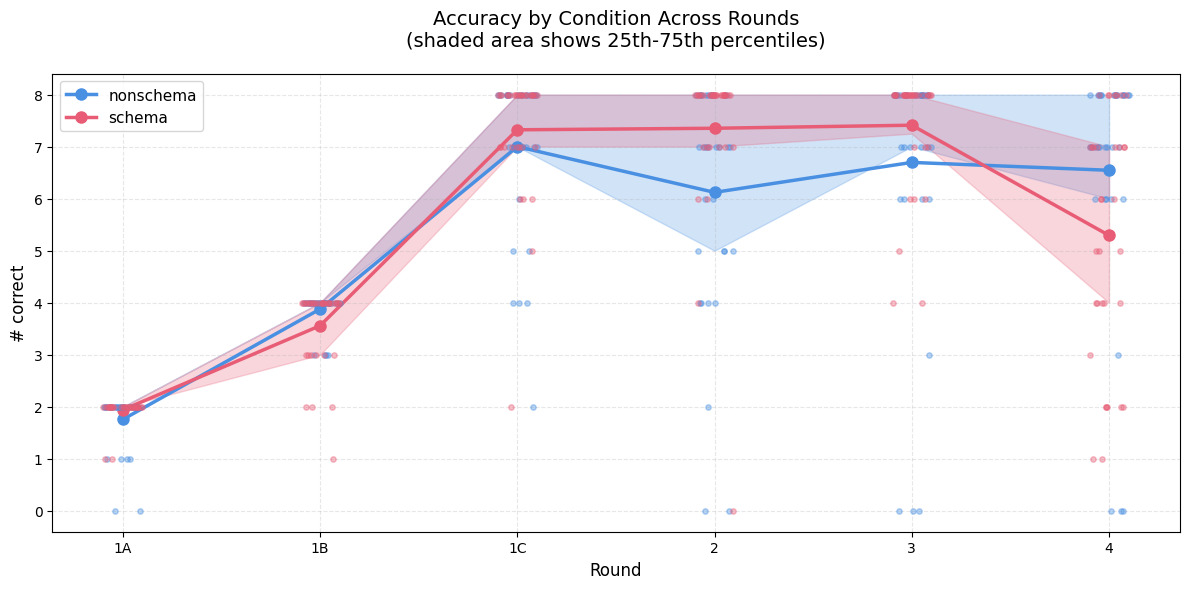

In [28]:
# Figure: Shaded area plot of accuracy (points) across rounds
# Mirrors the labeling time shaded area plot to show the accuracy side of the story
acc_cols = [col for col in data.columns if col.startswith("accuracy_")]

plot_data = []
for col in acc_cols:
    for idx, row in data.iterrows():
        plot_data.append({'round': col, 'accuracy': row[col], 'condition': row['treatment']})
plot_df = pd.DataFrame(plot_data)

def extract_round_label(col_name):
    return col_name.replace('accuracy_', '').upper()

fig, ax = plt.subplots(figsize=(12, 6))
color_map = {'nonschema': '#4A90E2', 'schema': '#E85D75'}
round_labels = [extract_round_label(col) for col in acc_cols]
x_positions = list(range(len(acc_cols)))

for condition in ['nonschema', 'schema']:
    x_vals, means, q25s, q75s = [], [], [], []
    for idx, col in enumerate(acc_cols):
        cond_data = plot_df[(plot_df['round'] == col) & (plot_df['condition'] == condition)]['accuracy'].dropna()
        if len(cond_data) > 0:
            x_vals.append(idx)
            means.append(cond_data.mean())
            q25s.append(cond_data.quantile(0.25))
            q75s.append(cond_data.quantile(0.75))
    ax.plot(x_vals, means, marker='o', linewidth=2.5, label=condition,
            color=color_map[condition], markersize=8)
    ax.fill_between(x_vals, q25s, q75s, alpha=0.25, color=color_map[condition])

for condition in ['nonschema', 'schema']:
    for idx, col in enumerate(acc_cols):
        cond_data = plot_df[(plot_df['round'] == col) & (plot_df['condition'] == condition)]['accuracy'].dropna()
        if len(cond_data) > 0:
            x_jitter = np.random.uniform(-0.1, 0.1, size=len(cond_data))
            ax.scatter(np.full(len(cond_data), idx) + x_jitter, cond_data,
                       alpha=0.4, color=color_map[condition], s=15, zorder=3)

ax.set_xlabel('Round', fontsize=12)
ax.set_ylabel('# correct', fontsize=12)
ax.set_title('Accuracy by Condition Across Rounds\n(shaded area shows 25th-75th percentiles)',
             fontsize=14, pad=20)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xticks(x_positions)
ax.set_xticklabels(round_labels)
plt.tight_layout()
plt.show()


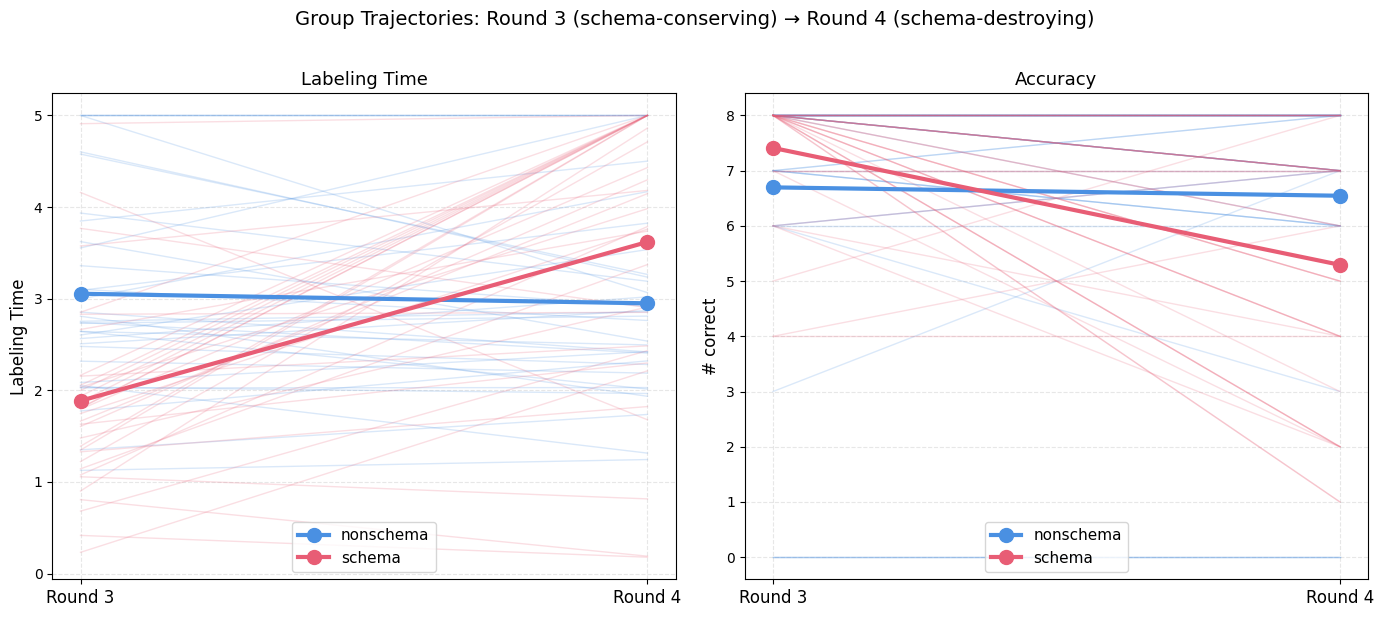

In [29]:
# Figure: R3 -> R4 slope plot (individual group trajectories + condition means)
# Shows the pivot from schema-conserving (R3) to schema-destroying (R4) change
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
color_map = {'nonschema': '#4A90E2', 'schema': '#E85D75'}

panels = [
    (axes[0], 'time_labeling_3', 'time_labeling_4', 'Labeling Time', True),
    (axes[1], 'accuracy_3', 'accuracy_4', '# correct', False),
]

for ax, col3, col4, ylabel, is_time in panels:
    for condition in ['nonschema', 'schema']:
        cond_data = data[data['treatment'] == condition]

        # Individual group lines
        for _, row in cond_data.iterrows():
            ax.plot([0, 1], [row[col3], row[col4]],
                    color=color_map[condition], alpha=0.2, linewidth=1)

        # Condition mean line
        mean3 = cond_data[col3].mean()
        mean4 = cond_data[col4].mean()
        ax.plot([0, 1], [mean3, mean4],
                color=color_map[condition], linewidth=3, marker='o', markersize=10,
                label=condition, zorder=5)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Round 3', 'Round 4'], fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    if is_time:
        ax.set_title('Labeling Time', fontsize=13)
        ax.set_yticks(range(0, 310, 60))
        ax.set_yticklabels(range(0, 6, 1))
    else:
        ax.set_title('Accuracy', fontsize=13)

fig.suptitle('Group Trajectories: Round 3 (schema-conserving) → Round 4 (schema-destroying)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


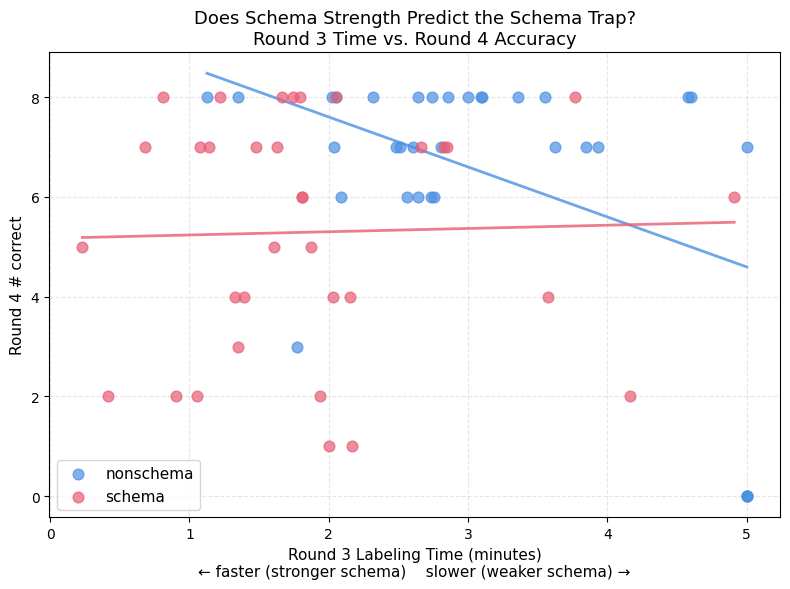

In [30]:
# Figure: Schema strength (R3 labeling time) vs. Round 4 accuracy
# Exploratory: do groups that internalised the schema most deeply suffer most in R4?
fig, ax = plt.subplots(figsize=(8, 6))
color_map = {'nonschema': '#4A90E2', 'schema': '#E85D75'}

for condition in ['nonschema', 'schema']:
    cond_data = data[data['treatment'] == condition]
    x = cond_data['time_labeling_3'].values
    y = cond_data['accuracy_4'].values
    ax.scatter(x, y, color=color_map[condition], alpha=0.7, s=60, label=condition, zorder=3)
    # Regression line
    if len(x) > 2:
        m, b = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, m * x_line + b, color=color_map[condition], linewidth=2, alpha=0.8)

ax.set_xlabel('Round 3 Labeling Time (minutes)\n← faster (stronger schema)    slower (weaker schema) →',
              fontsize=11)
ax.set_ylabel('Round 4 # correct', fontsize=11)
ax.set_title('Does Schema Strength Predict the Schema Trap?\nRound 3 Time vs. Round 4 Accuracy',
             fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xticks(range(0, 310, 60))
ax.set_xticklabels(range(0, 6, 1))
plt.tight_layout()
plt.show()


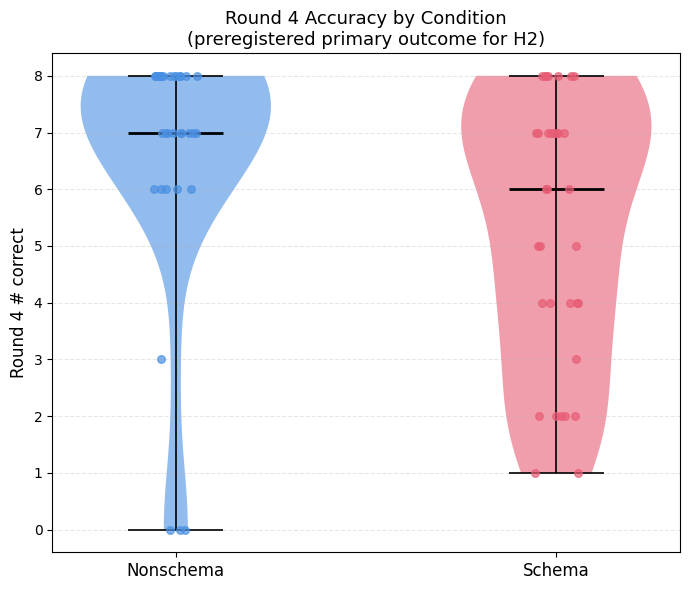

In [31]:
# Figure: Round 4 accuracy distribution by condition
# Clean head-to-head comparison for the preregistered H2 outcome
fig, ax = plt.subplots(figsize=(7, 6))
color_map = {'nonschema': '#4A90E2', 'schema': '#E85D75'}

violin_data = [data[data['treatment'] == cond]['accuracy_4'].dropna().values
               for cond in ['nonschema', 'schema']]
vp = ax.violinplot(violin_data, positions=[0, 1], showmedians=True, showmeans=False)

for patch, cond in zip(vp['bodies'], ['nonschema', 'schema']):
    patch.set_facecolor(color_map[cond])
    patch.set_alpha(0.6)
vp['cmedians'].set_color('black')
vp['cmedians'].set_linewidth(2)
for part in ['cbars', 'cmins', 'cmaxes']:
    vp[part].set_color('black')
    vp[part].set_linewidth(1.2)

np.random.seed(42)
for i, condition in enumerate(['nonschema', 'schema']):
    cond_data = data[data['treatment'] == condition]['accuracy_4'].dropna()
    x_jitter = np.random.uniform(-0.06, 0.06, size=len(cond_data))
    ax.scatter(np.full(len(cond_data), i) + x_jitter, cond_data,
               color=color_map[condition], alpha=0.7, s=30, zorder=3)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Nonschema', 'Schema'], fontsize=12)
ax.set_ylabel('Round 4 # correct', fontsize=12)
ax.set_title('Round 4 Accuracy by Condition\n(preregistered primary outcome for H2)', fontsize=13)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


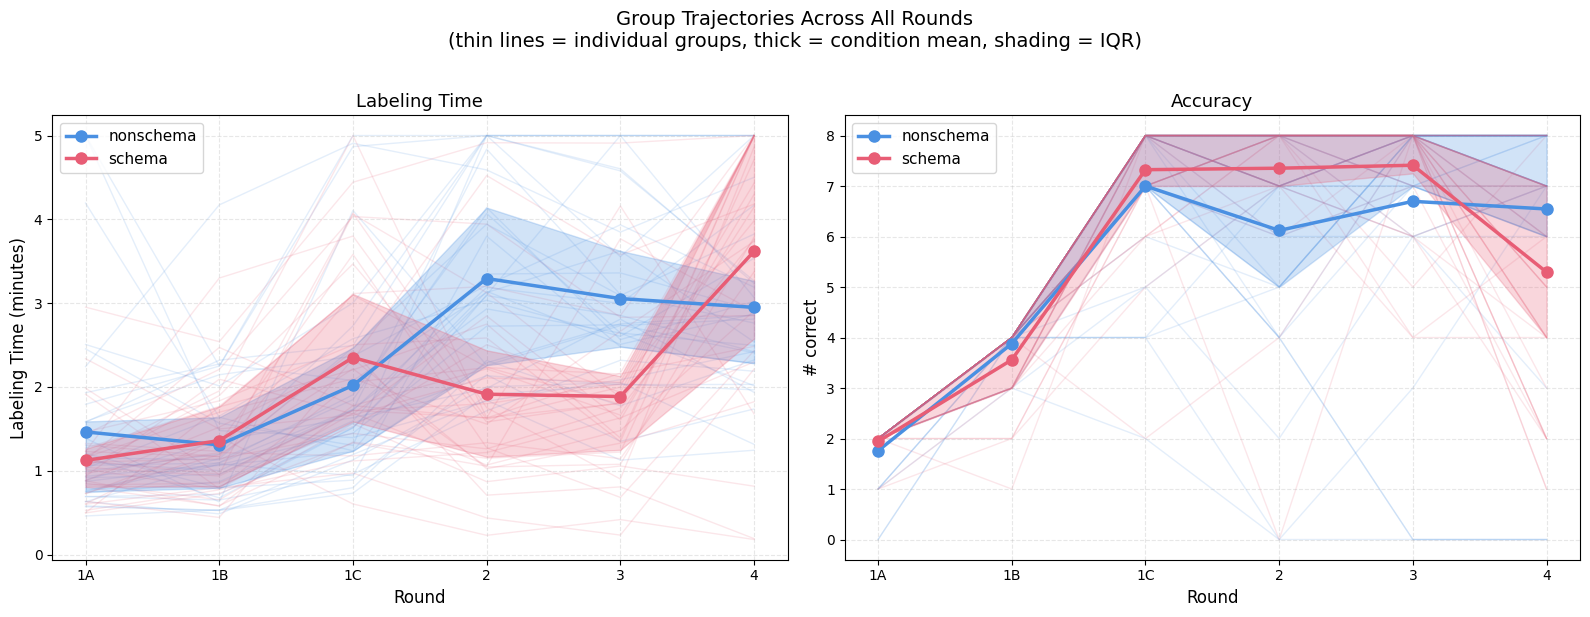

In [32]:
# Figure: Individual group trajectories + condition mean/IQR across all rounds
# Combines spaghetti lines (each group) with the shaded area summary
# Side-by-side: labeling time (left) and accuracy (right)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
color_map = {'nonschema': '#4A90E2', 'schema': '#E85D75'}

time_cols   = [col for col in data.columns if col.startswith("time_labeling_")]
acc_cols = [col for col in data.columns if col.startswith("accuracy_")]

panels = [
    (axes[0], time_cols,   'time',   'Labeling Time (minutes)', True),
    (axes[1], acc_cols,    'accuracy', '# correct', False),
]

def extract_label(col):
    return col.replace('time_labeling_', '').replace('accuracy_', '').upper()

for ax, cols, metric, ylabel, is_time in panels:
    x_positions = list(range(len(cols)))
    round_labels = [extract_label(c) for c in cols]

    # --- Individual group spaghetti lines ---
    for condition in ['nonschema', 'schema']:
        cond_data = data[data['treatment'] == condition]
        for _, row in cond_data.iterrows():
            y_vals = [row[c] for c in cols]
            ax.plot(x_positions, y_vals,
                    color=color_map[condition], alpha=0.15, linewidth=1, zorder=1)

    # --- Condition mean + IQR shading ---
    for condition in ['nonschema', 'schema']:
        cond_data = data[data['treatment'] == condition]
        means = [cond_data[c].mean() for c in cols]
        q25s  = [cond_data[c].quantile(0.25) for c in cols]
        q75s  = [cond_data[c].quantile(0.75) for c in cols]
        ax.plot(x_positions, means, marker='o', linewidth=2.5,
                color=color_map[condition], markersize=8, label=condition, zorder=3)
        ax.fill_between(x_positions, q25s, q75s,
                        alpha=0.25, color=color_map[condition], zorder=2)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(round_labels)
    ax.set_xlabel('Round', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    if is_time:
        ax.set_title('Labeling Time', fontsize=13)
        ax.set_yticks(range(0, 310, 60))
        ax.set_yticklabels(range(0, 6, 1))
    else:
        ax.set_title('Accuracy', fontsize=13)

fig.suptitle('Group Trajectories Across All Rounds\n(thin lines = individual groups, thick = condition mean, shading = IQR)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# TODO: maybe add the 95% CI for the means in this plot

# Figures formatted for PNAS

Saved figures/figure1.pdf and figures/figure1.png


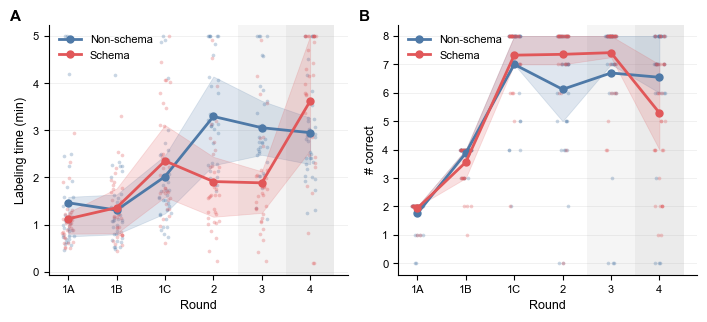


Fig. 1. Shared cognitive schemas accelerate coordination but impair adaptation under schema-destroying change.
(A) Labeling time and (B) accuracy (# correct) across all rounds for Schema (orange) and Non-schema (blue) groups.
Lines show condition means; shaded bands show the interquartile range (25th–75th percentiles); points show individual groups (jittered horizontally for clarity).
Rounds 1A–2 were condition-specific training rounds (Rounds 1A and 1B contained 2 and 4 images respectively; all other rounds contained 8).
Shaded background regions mark the preregistered test rounds: Round 3 introduced a schema-conserving environmental change (H1) and Round 4 introduced a schema-destroying change (H2).



In [33]:
# ── PNAS Figure 1 ──────────────────────────────────────────────────────────────
# Two-panel shaded area plot: labeling time (A) and accuracy (B) across all rounds
# Full page width (7.0 in). Styles applied locally via rc_context.

import os

pnas_style = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'lines.linewidth': 1.5,
    'lines.markersize': 5,
    'patch.linewidth': 0.6,
}
colors = {'nonschema': '#4E79A7', 'schema': '#E15759'}   # Tableau blue / red
labels = {'nonschema': 'Non-schema', 'schema': 'Schema'}

time_cols   = [c for c in data.columns if c.startswith('time_labeling_')]
acc_cols = [c for c in data.columns if c.startswith('accuracy_')]
round_lbl   = lambda c: c.replace('time_labeling_', '').replace('accuracy_', '').upper()

np.random.seed(42)
with plt.rc_context(pnas_style):
    fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.2))

    panels = [
        (axes[0], time_cols,   'Labeling time (min)',        True),
        (axes[1], acc_cols, '# correct',  False),
    ]

    for ax, cols, ylabel, is_time in panels:
        x = list(range(len(cols)))
        xlabels = [round_lbl(c) for c in cols]

        # Subtle shading: schema-conserving (R3) and schema-destroying (R4)
        ax.axvspan(3.5, 4.5, color='#f5f5f5', zorder=0, linewidth=0)
        ax.axvspan(4.5, 5.5, color='#ebebeb', zorder=0, linewidth=0)
        for condition in ['nonschema', 'schema']:
            cond = data[data['treatment'] == condition]
            means = [cond[c].mean() for c in cols]
            q25s  = [cond[c].quantile(0.25) for c in cols]
            q75s  = [cond[c].quantile(0.75) for c in cols]

            # Raw jittered points
            for xi, col in enumerate(cols):
                vals = cond[col].dropna().values
                jitter = np.random.uniform(-0.12, 0.12, len(vals))
                ax.scatter(xi + jitter, vals, color=colors[condition],
                           alpha=0.3, s=7, zorder=2, linewidths=0)

            # IQR band + mean line
            ax.fill_between(x, q25s, q75s, alpha=0.18,
                            color=colors[condition], zorder=3)
            ax.plot(x, means, marker='o', linewidth=2,
                    color=colors[condition], markersize=5,
                    label=labels[condition], zorder=4)

        ax.set_xticks(x)
        ax.set_xticklabels(xlabels)
        ax.set_xlabel('Round')
        ax.set_ylabel(ylabel)
        ax.legend(frameon=False, loc='upper left')
        ax.grid(axis='y', alpha=0.25, linewidth=0.5, linestyle='-')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if is_time:
            ax.set_yticks(range(0, 310, 60))
            ax.set_yticklabels(range(0, 6, 1))

    # Panel labels
    for ax, lbl in zip(axes, ['A', 'B']):
        ax.text(-0.13, 1.06, lbl, transform=ax.transAxes,
                fontsize=11, fontweight='bold', va='top')

    plt.tight_layout(pad=0.8, w_pad=1.5)
    os.makedirs('figures', exist_ok=True)
    plt.savefig('figures/figure1.pdf', dpi=600, bbox_inches='tight')
    plt.savefig('figures/figure1.png', dpi=600, bbox_inches='tight')
    print("Saved figures/figure1.pdf and figures/figure1.png")
    plt.show()

print("""
Fig. 1. Shared cognitive schemas accelerate coordination but impair adaptation under schema-destroying change.
(A) Labeling time and (B) accuracy (# correct) across all rounds for Schema (orange) and Non-schema (blue) groups.
Lines show condition means; shaded bands show the interquartile range (25th–75th percentiles); points show individual groups (jittered horizontally for clarity).
Rounds 1A–2 were condition-specific training rounds (Rounds 1A and 1B contained 2 and 4 images respectively; all other rounds contained 8).
Shaded background regions mark the preregistered test rounds: Round 3 introduced a schema-conserving environmental change (H1) and Round 4 introduced a schema-destroying change (H2).
""")

Saved figures/figure2.pdf and figures/figure2.png


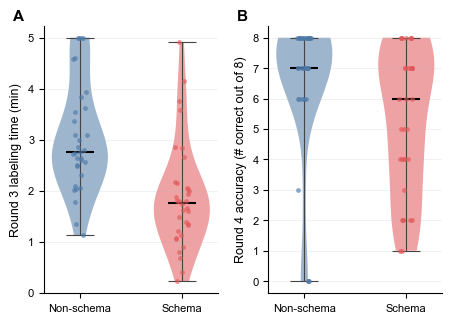


Fig. 2. Schema condition reduces labeling time under schema-conserving change but impairs accuracy under schema-destroying change.
(A) Round 3 labeling time (H1) and (B) Round 4 accuracy (H2) by condition.
Violins show the full distribution; horizontal lines show medians; points show individual groups (jittered horizontally for clarity).
H1 was tested with a one-tailed Welch’s t-test (Schema < Non-schema); H2 was tested with a one-tailed Mann–Whitney U test using a permutation-based p-value (Schema < Non-schema).



In [34]:
# ── PNAS Figure 2 ──────────────────────────────────────────────────────────────
# Two-panel hypothesis tests: R3 labeling time (A, H1) and R4 accuracy (B, H2)
# 1.5-column width (4.5 in). Styles applied locally via rc_context.

pnas_style = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'lines.linewidth': 1.5,
    'patch.linewidth': 0.6,
}
colors = {'nonschema': '#4E79A7', 'schema': '#E15759'}   # Tableau blue / red
xlabels = ['Non-schema', 'Schema']

np.random.seed(42)
with plt.rc_context(pnas_style):
    fig, axes = plt.subplots(1, 2, figsize=(4.5, 3.2))

    panels = [
        (axes[0], 'time_labeling_3', 'Round 3 labeling time (min)', True,  'A'),
        (axes[1], 'accuracy_4', 'Round 4 accuracy (# correct out of 8)', False, 'B'),
    ]

    for ax, col, ylabel, is_time, panel_lbl in panels:
        violin_data = [data[data['treatment'] == cond][col].dropna().values
                       for cond in ['nonschema', 'schema']]

        vp = ax.violinplot(violin_data, positions=[0, 1],
                           showmedians=True, showmeans=False, widths=0.55)

        # Style violin bodies
        for body, cond in zip(vp['bodies'], ['nonschema', 'schema']):
            body.set_facecolor(colors[cond])
            body.set_alpha(0.55)
            body.set_linewidth(0.6)
        vp['cmedians'].set_color('black')
        vp['cmedians'].set_linewidth(1.5)
        for part in ['cbars', 'cmins', 'cmaxes']:
            vp[part].set_color('#444444')
            vp[part].set_linewidth(0.8)

        # Jittered strip
        for i, cond in enumerate(['nonschema', 'schema']):
            vals = data[data['treatment'] == cond][col].dropna().values
            jitter = np.random.uniform(-0.07, 0.07, len(vals))
            ax.scatter(i + jitter, vals, color=colors[cond],
                       alpha=0.65, s=12, zorder=3, linewidths=0)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(xlabels)
        ax.set_ylabel(ylabel)
        ax.grid(axis='y', alpha=0.25, linewidth=0.5, linestyle='-')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if is_time:
            ax.set_yticks(range(0, 310, 60))
            ax.set_yticklabels(range(0, 6, 1))

        ax.text(-0.18, 1.06, panel_lbl, transform=ax.transAxes,
                fontsize=11, fontweight='bold', va='top')

    plt.tight_layout(pad=0.8, w_pad=1.5)
    plt.savefig('figures/figure2.pdf', dpi=600, bbox_inches='tight')
    plt.savefig('figures/figure2.png', dpi=600, bbox_inches='tight')
    print("Saved figures/figure2.pdf and figures/figure2.png")
    plt.show()

print("""
Fig. 2. Schema condition reduces labeling time under schema-conserving change but impairs accuracy under schema-destroying change.
(A) Round 3 labeling time (H1) and (B) Round 4 accuracy (H2) by condition.
Violins show the full distribution; horizontal lines show medians; points show individual groups (jittered horizontally for clarity).
H1 was tested with a one-tailed Welch\u2019s t-test (Schema < Non-schema); H2 was tested with a one-tailed Mann\u2013Whitney U test using a permutation-based p-value (Schema < Non-schema).
""")

In [35]:
# ── Table 1: Descriptive statistics across all rounds ─────────────────────────
# Mean (SD) for labeling time (minutes) and accuracy (# correct) by condition and round.
# Column order: Schema Time, Non-schema Time, Schema Accuracy, Non-schema Accuracy

rounds = ['1a', '1b', '1c', '2', '3', '4']

rows = []
for r in rounds:
    row = {'Round': r.upper()}
    for metric, col_prefix, divisor in [('time', 'time_labeling', 60), ('accuracy', 'accuracy', 1)]:
        for cond, label in [('schema', 'Schema'), ('nonschema', 'Non-schema')]:
            cond_data = data[data['treatment'] == cond]
            vals = cond_data[f'{col_prefix}_{r}'].dropna() / divisor
            col_name = 'Time' if metric == 'time' else 'Accuracy'
            row[f'{col_name} {label}'] = f"{vals.mean():.2f} ({vals.std(ddof=1):.2f})"
    rows.append(row)

t1 = pd.DataFrame(rows).set_index('Round')[
    ['Time Schema', 'Time Non-schema', 'Accuracy Schema', 'Accuracy Non-schema']
]

print("Table 1. Labeling time (min) and accuracy (# correct) by condition and round.")
print("Values are mean (SD). Rounds 3 and 4 are the preregistered test rounds.")
print()
print(t1.to_string())

# ── Markdown ───────────────────────────────────────────────────────────────────
print("\n**Table 1.** Labeling time (min) and accuracy (# correct, 0\u20138) by condition and round. Values are mean (SD).\n")
print("| Round | Time Schema | Time Non-schema | Accuracy Schema | Accuracy Non-schema |")
print("|-------|-------------|-----------------|-----------------|---------------------|")
for r in rounds:
    row_vals = [r.upper()]
    for metric, col_prefix, divisor in [('time', 'time_labeling', 60), ('accuracy', 'accuracy', 1)]:
        for cond in ['schema', 'nonschema']:
            cond_data = data[data['treatment'] == cond]
            vals = cond_data[f'{col_prefix}_{r}'].dropna() / divisor
            row_vals.append(f"{vals.mean():.2f} ({vals.std(ddof=1):.2f})")
    print("| " + " | ".join(row_vals) + " |")

# ── LaTeX ──────────────────────────────────────────────────────────────────────
latex = []
latex.append(r"\begin{table*}[ht]")
latex.append(r"\centering")
latex.append(r"\caption{Descriptive statistics by condition and round. Values are mean (SD). Rounds 3 and 4 are the preregistered test rounds.}")
latex.append(r"\label{tab:descriptive}")
latex.append(r"\begin{tabular}{lllll}")
latex.append(r"\toprule")
latex.append(r" & \multicolumn{2}{c}{Labeling time (min)} & \multicolumn{2}{c}{Accuracy} \\")
latex.append(r"\cmidrule(lr){2-3} \cmidrule(lr){4-5}")
latex.append(r"Round & Schema & Non-schema & Schema & Non-schema \\")
latex.append(r"\midrule")
for r in rounds:
    if r == '3':
        latex.append(r"\midrule")
    row_vals = [r.upper()]
    for metric, col_prefix, divisor in [('time', 'time_labeling', 60), ('accuracy', 'accuracy', 1)]:
        for cond in ['schema', 'nonschema']:
            cond_data = data[data['treatment'] == cond]
            vals = cond_data[f'{col_prefix}_{r}'].dropna() / divisor
            row_vals.append(f"{vals.mean():.2f} ({vals.std(ddof=1):.2f})")
    latex.append(" & ".join(row_vals) + r" \\")
latex.append(r"\bottomrule")
latex.append(r"\end{tabular}")
latex.append(r"\end{table*}")
print()
print("LaTeX:")
print("\n".join(latex))


Table 1. Labeling time (min) and accuracy (# correct) by condition and round.
Values are mean (SD). Rounds 3 and 4 are the preregistered test rounds.

       Time Schema Time Non-schema Accuracy Schema Accuracy Non-schema
Round                                                                 
1A     1.12 (0.53)     1.46 (1.18)     1.94 (0.24)         1.76 (0.56)
1B     1.36 (0.66)     1.31 (0.77)     3.56 (0.79)         3.88 (0.33)
1C     2.35 (1.12)     2.02 (1.17)     7.32 (1.22)         7.00 (1.58)
2      1.91 (1.09)     3.29 (1.15)     7.35 (1.55)         6.12 (2.26)
3      1.89 (1.04)     3.05 (1.07)     7.41 (1.16)         6.70 (2.39)
4      3.62 (1.48)     2.95 (1.05)     5.29 (2.34)         6.55 (2.35)

**Table 1.** Labeling time (min) and accuracy (# correct, 0–8) by condition and round. Values are mean (SD).

| Round | Time Schema | Time Non-schema | Accuracy Schema | Accuracy Non-schema |
|-------|-------------|-----------------|-----------------|---------------------|
| 1A |

In [36]:
# ── Table 2: Primary hypothesis test results ──────────────────────────────────
# Uses variables computed in cells 22 (H1) and 23 (H2).
# H1: Welch's t-test on R3 labeling time (seconds → minutes here).
# H2: Mann-Whitney U (permutation-based) on R4 accuracy.

import numpy as np

# ── H1: recompute CI with correct Welch-Satterthwaite df ──────────────────────
n1, n2 = len(schema_time3), len(nonschema_time3)
s1, s2 = schema_time3.var(ddof=1), nonschema_time3.var(ddof=1)
se_diff = np.sqrt(s1/n1 + s2/n2)
df_ws = (s1/n1 + s2/n2)**2 / ((s1/n1)**2/(n1-1) + (s2/n2)**2/(n2-1))
t_crit = stats.t.ppf(0.975, df=df_ws)
h1_ci_lo = (mean_diff - t_crit * se_diff) / 60
h1_ci_hi = (mean_diff + t_crit * se_diff) / 60
h1_diff_min = mean_diff / 60

rows = [
    {
        'Hypothesis':    'H1: Round 3 labeling time',
        'Test':          "Welch's t",
        'Schema':        f"{schema_time3.mean()/60:.2f} ({schema_time3.std(ddof=1)/60:.2f})",
        'Non-schema':    f"{nonschema_time3.mean()/60:.2f} ({nonschema_time3.std(ddof=1)/60:.2f})",
        'Difference':    f"{h1_diff_min:.2f} [{h1_ci_lo:.2f}, {h1_ci_hi:.2f}]",
        'Effect size':   f"d = {cohens_d:.3f}",
        'Statistic':     f"t({df_ws:.1f}) = {t_stat:.3f}",
        'p (one-tailed)': f"{p_val:.4f}",
    },
    {
        'Hypothesis':    'H2: Round 4 accuracy',
        'Test':          u'Mann\u2013Whitney U\u2020',
        'Schema':        f"{schema_mean4:.2f} ({schema_points4.std(ddof=1):.2f}), mdn = {schema_median4:.1f}",
        'Non-schema':    f"{nonschema_mean4:.2f} ({nonschema_points4.std(ddof=1):.2f}), mdn = {nonschema_median4:.1f}",
        'Difference':    f"HL = {hl_estimate:.2f} [{hl_ci[0]:.2f}, {hl_ci[1]:.2f}]",
        'Effect size':   f"\u03b4 = {cliff_d:.3f}",
        'Statistic':     f"U = {observed_u:.1f}",
        'p (one-tailed)': f"{p_perm:.4f}",
    },
]

t2 = pd.DataFrame(rows).set_index('Hypothesis')

print("Table 2. Primary hypothesis test results.")
print("H1: values in minutes; difference = Schema - Non-schema mean (95% CI, Welch-Satterthwaite).")
print("H2: values on 0-8 scale; difference = Hodges-Lehmann estimate (95% bootstrap CI).")
print("\u2020 Permutation-based p-value, 9,999 permutations, seed = 42.")
print()
print(t2.to_string())

# ── LaTeX ──────────────────────────────────────────────────────────────────────
latex = []
latex.append(r"\begin{table*}[ht]")
latex.append(r"\centering")
latex.append(r"\caption{Primary hypothesis test results. H1 values in minutes; difference is mean difference (Schema $-$ Non-schema) with 95\% CI (Welch--Satterthwaite). H2 values on 0--8 scale; difference is Hodges--Lehmann estimate with 95\% bootstrap CI. $^{\dag}$Permutation-based $p$-value, 9,999 permutations.}")
latex.append(r"\label{tab:results}")
latex.append(r"\begin{tabular}{llllllll}")
latex.append(r"\toprule")
latex.append(r"Hypothesis & Test & Schema & Non-schema & Difference & Effect size & Statistic & $p$ \\")
latex.append(r"\midrule")
for _, row in t2.iterrows():
    vals = [
        row.name.replace("&", "\&"),
        row["Test"].replace(u"\u2020", r"$^{\dag}$").replace(u"\u2013", "--"),
        row["Schema"],
        row["Non-schema"],
        row["Difference"],
        row["Effect size"].replace(u"\u03b4", r"$\delta$"),
        row["Statistic"],
        row["p (one-tailed)"],
    ]
    latex.append(" & ".join(vals) + r" \\")
latex.append(r"\bottomrule")
latex.append(r"\end{tabular}")
latex.append(r"\end{table*}")

print()
print("LaTeX:")
print("\n".join(latex))


# ── Markdown ───────────────────────────────────────────────────────────────────
print("\n**Table 2.** Primary hypothesis test results.\n")
print("| Hypothesis | Test | Schema | Non-schema | Difference | Effect size | Statistic | p |")
print("|------------|------|--------|------------|------------|-------------|-----------|---|")
for row in rows:
    vals = [
        row['Hypothesis'],
        row['Test'].replace(u'\u2020', '†').replace(u'\u2013', '–'),
        row['Schema'],
        row['Non-schema'],
        row['Difference'],
        row['Effect size'].replace(u'\u03b4', 'δ'),
        row['Statistic'],
        row['p (one-tailed)'],
    ]
    print("| " + " | ".join(vals) + " |")
print("\n† Permutation-based p-value, 9,999 permutations, seed = 42.")


Table 2. Primary hypothesis test results.
H1: values in minutes; difference = Schema - Non-schema mean (95% CI, Welch-Satterthwaite).
H2: values on 0-8 scale; difference = Hodges-Lehmann estimate (95% bootstrap CI).
† Permutation-based p-value, 9,999 permutations, seed = 42.

                                      Test                  Schema              Non-schema                Difference Effect size         Statistic p (one-tailed)
Hypothesis                                                                                                                                                       
H1: Round 3 labeling time        Welch's t             1.89 (1.04)             3.05 (1.07)      -1.17 [-1.68, -0.65]  d = -1.110  t(64.8) = -4.542         0.0000
H2: Round 4 accuracy       Mann–Whitney U†  5.29 (2.34), mdn = 6.0  6.55 (2.35), mdn = 7.0  HL = -1.00 [-3.00, 0.00]  δ = -0.354         U = 362.5         0.0050

LaTeX:
\begin{table*}[ht]
\centering
\caption{Primary hypothesis test resu

# Exploratory analysis

In [ ]:
import json
from textwrap import dedent



# Minimal JSON schema you can validate against (optional)
SCORE_SCHEMA = {
    "type": "object",
    "additionalProperties": False,
    "properties": {k: {"type": "integer", "minimum": 0, "maximum": 3} for k in SCORE_KEYS},
    "required": SCORE_KEYS,
}

# Full rubric text to include in every scoring prompt (stateless / independent scoring)
RUBRIC_TEXT = dedent("""
You are scoring responses from an experiment in which participants were asked to label 4 sets of images, and then recall the labels
that they chose for each set.

                     
In one condition of the experiment, participants were shown images that could be labeled using a "schema", 
in which a set of features consistently varied across the images within the set. 

The features were:
- hat/hair color (2 options)
- hat/hair orientation (2 options)
- arm/hand color (2 options)
- arm/hand orientation (2 options)               
- foot/leg color (2 options)
- foot/leg orientation (2 options)
- eye position (3 options for each eye)

As there were 8 images in each set, participants could construct a schema by using three binary features,
in various combinations. 
                     
In the second condition, participants were shown images that did not contain any consistent features across the set, so there was no schema to be formed.
Instead, the images could be given "holistic" descriptions, such as "owl", "wheel", etc.

All images in both conditions had feet and eyes and hands, but in the schema condition these features were systematically varied across the set, while in the nonschema condition they were not.                     

Sometimes, participants in the schema condition would decide not to use a schema, or to use a partial schema and mix in other descriptions.
Also, sometimes participants in the nons                                          


""")

def build_scoring_prompt(explanation_text: str) -> str:
    """Return a single prompt that asks an LLM to produce ONLY JSON with 10 integer scores."""
    explanation_text = (explanation_text or "").strip()
    return RUBRIC_TEXT + "\n\nEXPLANATION:\n" + explanation_text

def parse_scores(json_text: str) -> dict:
    """Parse and lightly validate the model output."""
    data = json.loads(json_text)
    missing = [k for k in SCORE_KEYS if k not in data]
    extra = [k for k in data.keys() if k not in SCORE_KEYS]
    if missing or extra:
        raise ValueError(f"Bad keys. Missing={missing} Extra={extra}")
    for k in SCORE_KEYS:
        v = data[k]
        if not isinstance(v, int) or v < 0 or v > 3:
            raise ValueError(f"Bad value for {k}: {v}")
    return data

# Example usage (manual):
example_text = "They failed twice so I don't want to risk losing points, but I'll try a low bid to see what happens."
prompt = build_scoring_prompt(example_text)
print(prompt[:600] + "...\n")
print("Expected output example:")
print(json.dumps({
    "TrackRecord_Competence": 2,
    "RiskAversion_PointProtection": 2,
    "ExpectedValue_ProbabilityGamble": 0,
    "BidStrategy_TestingWaters": 1,
    "Incentives_EffortCostsTaxiPhone": 0,
    "CommunicationDifficulty_Ambiguity": 0,
    "CrossGroupLabelMismatch": 0,
    "Fairness_Norms_Split": 0,
    "ProSocial_KeepPlaying_GiveChance": 1,
    "NonExplanation_Noise": 0,
}, indent=2))

NameError: name 'SCORE_KEYS' is not defined

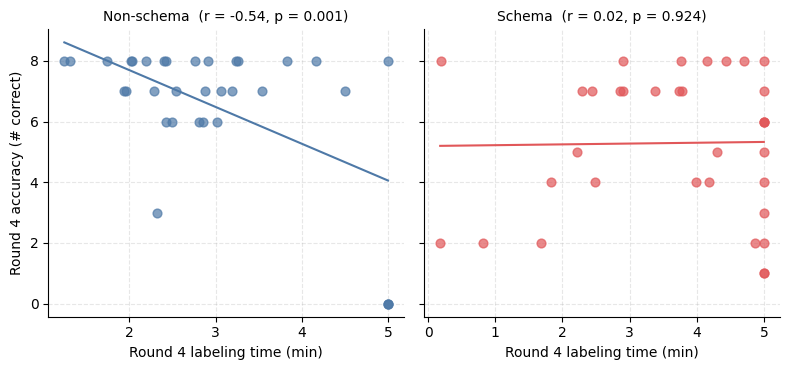

In [42]:
# Round 4: accuracy vs labeling time by condition
from scipy.stats import pearsonr

fig, axes = plt.subplots(1, 2, figsize=(8, 3.8), sharey=True)
colors = {'nonschema': '#4E79A7', 'schema': '#E15759'}
titles = {'nonschema': 'Non-schema', 'schema': 'Schema'}

for ax, cond in zip(axes, ['nonschema', 'schema']):
    cond_data = data[data['treatment'] == cond]
    x = cond_data['time_labeling_4'] / 60
    y = cond_data['accuracy_4']

    ax.scatter(x, y, color=colors[cond], alpha=0.7, s=40, zorder=3)

    # regression line
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, color=colors[cond], linewidth=1.5)

    r, p = pearsonr(x, y)
    ax.set_title(f"{titles[cond]}  (r = {r:.2f}, p = {p:.3f})", fontsize=10)
    ax.set_xlabel('Round 4 labeling time (min)')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Round 4 accuracy (# correct)')
plt.tight_layout()
plt.show()


- Pull out the words people use to label the images and see if there's consensus
- look at just the volume of conversation in each round, by condition.
- 

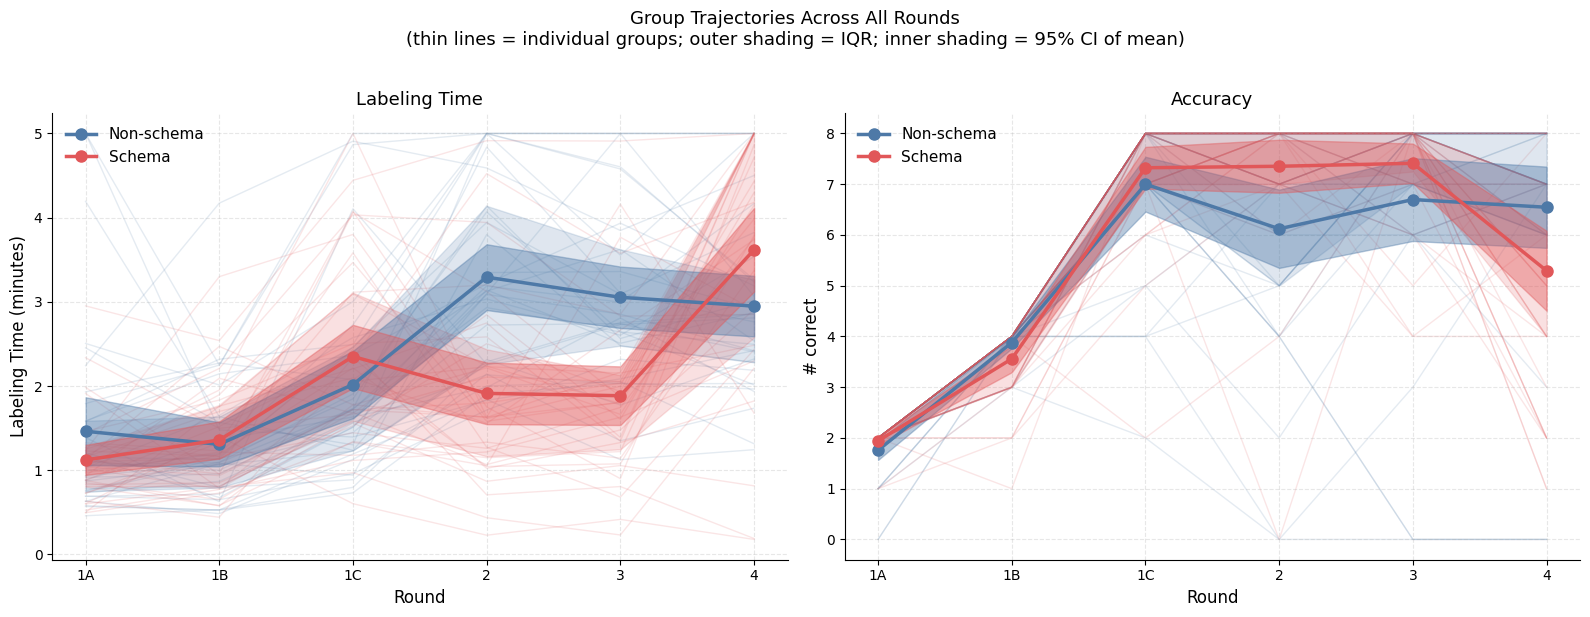

In [43]:
# Figure: Individual group trajectories + condition mean/IQR + 95% CI of mean
# IQR = lighter shading; 95% CI of the mean = slightly darker inner shading

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
color_map = {'nonschema': '#4E79A7', 'schema': '#E15759'}
labels    = {'nonschema': 'Non-schema', 'schema': 'Schema'}

time_cols = [col for col in data.columns if col.startswith("time_labeling_")]
acc_cols  = [col for col in data.columns if col.startswith("accuracy_")]

panels = [
    (axes[0], time_cols,  'Labeling Time (minutes)', True),
    (axes[1], acc_cols,   '# correct',               False),
]

def extract_label(col):
    return col.replace('time_labeling_', '').replace('accuracy_', '').upper()

for ax, cols, ylabel, is_time in panels:
    x = list(range(len(cols)))
    xlabels = [extract_label(c) for c in cols]

    # --- Spaghetti lines ---
    for condition in ['nonschema', 'schema']:
        cond_data = data[data['treatment'] == condition]
        for _, row in cond_data.iterrows():
            ax.plot(x, [row[c] for c in cols],
                    color=color_map[condition], alpha=0.15, linewidth=1, zorder=1)

    # --- IQR + 95% CI of mean + mean line ---
    for condition in ['nonschema', 'schema']:
        cond_data = data[data['treatment'] == condition]
        n = len(cond_data)
        means = np.array([cond_data[c].mean() for c in cols])
        sems  = np.array([cond_data[c].sem()  for c in cols])
        q25s  = np.array([cond_data[c].quantile(0.25) for c in cols])
        q75s  = np.array([cond_data[c].quantile(0.75) for c in cols])
        ci95  = 1.96 * sems   # approx 95% CI half-width

        # IQR — lightest
        ax.fill_between(x, q25s, q75s,
                        alpha=0.18, color=color_map[condition], zorder=2)
        # 95% CI of mean — slightly darker inner band
        ax.fill_between(x, means - ci95, means + ci95,
                        alpha=0.40, color=color_map[condition], zorder=3)
        # Mean line
        ax.plot(x, means, marker='o', linewidth=2.5, markersize=8,
                color=color_map[condition], label=labels[condition], zorder=4)

    ax.set_xticks(x)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel('Round', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.legend(fontsize=11, frameon=False)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if is_time:
        ax.set_title('Labeling Time', fontsize=13)
        ax.set_yticks(range(0, 310, 60))
        ax.set_yticklabels(range(0, 6, 1))
    else:
        ax.set_title('Accuracy', fontsize=13)

fig.suptitle(
    'Group Trajectories Across All Rounds\n'
    '(thin lines = individual groups; outer shading = IQR; inner shading = 95% CI of mean)',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()
